# Лекція 3 - Оптимізація та регуляризація в нейронних мережах


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 5  
**Тема лекції:** Оптимізація та регуляризація в нейронних мережах

## Цілі лекції

1. [Датасет](#0)
2. [Mini-Batch GD: перехід до PyTorch](#1)
3. [Проблеми ванільного SGD](#2)
4. [Momentum та Nesterov](#3)
5. [RMSProp → Adam → AdamW](#4)
6. [Learning Rate Scheduling](#5)
7. [Gradient Clipping](#6)
8. [L2-регуляризація та Weight Decay](#7)
9. [Dropout](#8)
10. [Рання зупинка (Early Stopping)](#9)
11. [Ініціалізація ваг](#10)
12. [Batch Normalization: огляд](#11)
13. [Порівняльний експеримент](#12)
14. [Підсумки](#summary)

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as sched
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


## 0. Складний синтетичний датасет <a id="0"></a>

Для демонстрації ефектів оптимізації та регуляризації потрібен датасет, де:
- легко **перенавчитись** (багато ознак, шум, кластерна структура)
- різні методи дають **чітко різні результати**

| Параметр | Значення |
|---|---|
| Кількість зразків | 2000 |
| Ознаки: всього / інформативних / надлишкових / повторюваних | 20 / 5 / 5 / 2 |
| Кластерів на клас | 2 |
| Розділення класів (`class_sep`) | 0.6 |
| Шум міток (`flip_y`) | 5% |

8 шумових ознак гарантують тенденцію до перенавчання без регуляризації.

In [3]:
# Create dataset
X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=5,
    n_redundant=5, n_repeated=2, n_clusters_per_class=2,
    class_sep=0.6, flip_y=0.05, random_state=42
)

# 60 / 20 / 20 split
X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)
X_val_raw, X_te_raw, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr_raw)
X_val = scaler.transform(X_val_raw)
X_te  = scaler.transform(X_te_raw)

print(f'Train: {X_tr.shape}  Val: {X_val.shape}  Test: {X_te.shape}')
print(f'Class balance - train: {np.bincount(y_tr)}')

Train: (1200, 20)  Val: (400, 20)  Test: (400, 20)
Class balance - train: [597 603]


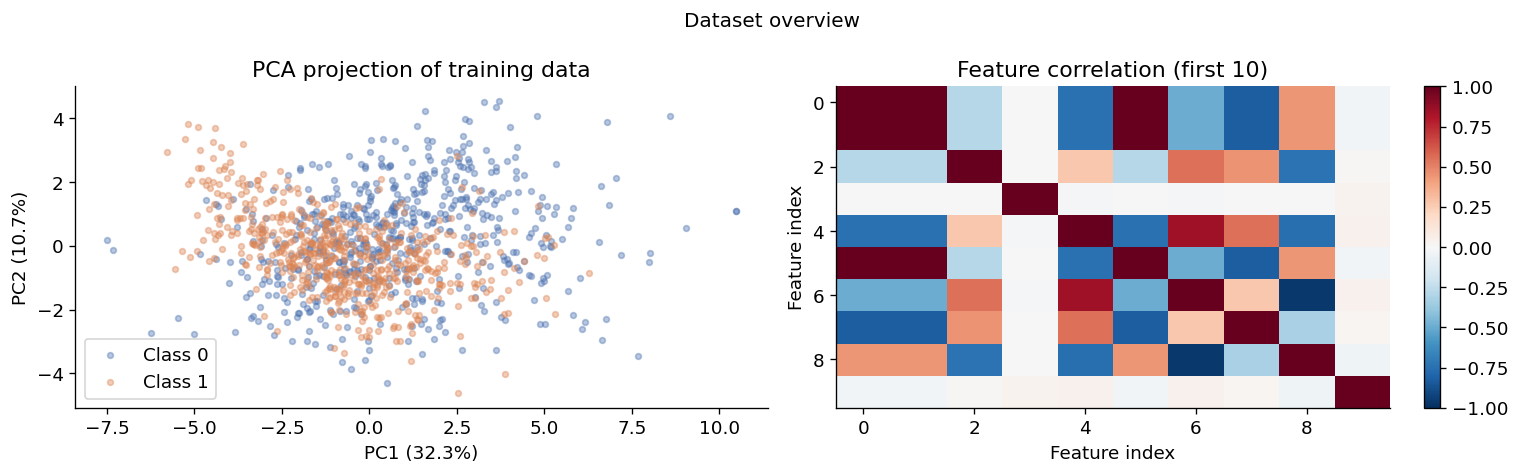

In [4]:
# PCA projection + feature correlation
pca = PCA(n_components=2, random_state=42)
Xp  = pca.fit_transform(X_tr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for cls, c in zip([0, 1], COLORS):
    m = y_tr == cls
    ax.scatter(Xp[m, 0], Xp[m, 1], c=c, s=12, alpha=0.4, label=f'Class {cls}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA projection of training data'); ax.legend()

ax = axes[1]
corr = np.corrcoef(X_tr[:, :10].T)
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Feature correlation (first 10)')
ax.set_xlabel('Feature index'); ax.set_ylabel('Feature index')
plt.colorbar(im, ax=ax)

plt.suptitle('Dataset overview', fontsize=12)
plt.tight_layout(); plt.show()

Бачимо класи, що перетинаються (PCA-проєкція), та кореляційну структуру (надлишкові ознаки). Це і є наше «поле гри» для всієї лекції.

In [5]:
# Convert to PyTorch tensors + DataLoaders
def to_t(X, y=None):
    Xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    if y is None: return Xt
    return Xt, torch.tensor(y, dtype=torch.float32).to(DEVICE)

Xtr_t, ytr_t   = to_t(X_tr,  y_tr)
Xval_t, yval_t = to_t(X_val, y_val)
Xte_t,  yte_t  = to_t(X_te,  y_te)

BATCH_SIZE   = 64
train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t),
                          batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
small_loader = DataLoader(TensorDataset(Xtr_t[:200], ytr_t[:200]),
                          batch_size=32,  shuffle=True,
                          generator=torch.Generator().manual_seed(42))

print(f'Batches per epoch (batch_size={BATCH_SIZE}): {len(train_loader)}')

Batches per epoch (batch_size=64): 19


In [6]:
# Base MLP factory - used throughout the lecture
def make_mlp(hidden=(64, 32), dropout_p=0.0, init='he'):
    """3-layer MLP with optional dropout and configurable weight init."""
    layers, sizes = [], [20] + list(hidden) + [1]
    for i in range(len(sizes) - 1):
        lin = nn.Linear(sizes[i], sizes[i + 1])
        if init == 'xavier':
            nn.init.xavier_uniform_(lin.weight)
        elif init == 'he':
            nn.init.kaiming_uniform_(lin.weight, nonlinearity='relu')
        elif init == 'zeros':
            nn.init.zeros_(lin.weight)
        # else: PyTorch default (uniform Kaiming)
        layers.append(lin)
        if i < len(sizes) - 2:          # hidden layers only
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
    layers.append(nn.Sigmoid())
    return nn.Sequential(*layers).to(DEVICE)

print(make_mlp())

Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
  (5): Sigmoid()
)


In [7]:
# Generic training loop (used for all experiments)
def train_model(model, optimizer, loader, val_X, val_y,
                n_epochs=150, patience=None, clip=None, scheduler=None):
    """Returns (train_losses, val_losses, epochs_run)."""
    criterion = nn.BCELoss()
    tr_hist, vl_hist = [], []
    best_val, best_state, no_imp = float('inf'), None, 0

    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(-1), yb)
            loss.backward()
            if clip:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            ep_loss += loss.item()

        model.eval()
        with torch.no_grad():
            vl = criterion(model(val_X).squeeze(-1), val_y).item()

        tr_hist.append(ep_loss / len(loader))
        vl_hist.append(vl)

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(vl)
            else:
                scheduler.step()

        if patience:
            if vl < best_val - 1e-4:
                best_val, no_imp = vl, 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                no_imp += 1
                if no_imp >= patience:
                    if best_state: model.load_state_dict(best_state)
                    return tr_hist, vl_hist, epoch + 1

    return tr_hist, vl_hist, n_epochs

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return ((model(X).squeeze(-1) >= 0.5).float() == y).float().mean().item()

print('Utilities ready.')

Utilities ready.


---
## 1. Mini-Batch GD: перехід до PyTorch <a id="1"></a>

На тижнях 1–2 ми вручну реалізували три варіанти градієнтного спуску. Нагадаємо ключові формули та подивимось, як вони відображаються в PyTorch.

### Три варіанти градієнтного спуску

**Batch GD (BGD)** - оновлення по всіх $N$ зразках:
$$\theta \leftarrow \theta - \eta \cdot \frac{1}{N}\sum_{i=1}^N \nabla_\theta \mathcal{L}(\theta; x^{(i)}, y^{(i)})$$

**Stochastic GD (SGD)** - оновлення по одному зразку:
$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}(\theta; x^{(i)}, y^{(i)})$$

**Mini-Batch GD (MBGD)** - оновлення по підмножині $|B|$ зразків:
$$\theta \leftarrow \theta - \eta \cdot \frac{1}{|B|}\sum_{i \in B} \nabla_\theta \mathcal{L}(\theta; x^{(i)}, y^{(i)})$$

> 💡 **У PyTorch `torch.optim.SGD` реалізує саме MBGD** - він виконує крок по будь-якому градієнту, який приходить з `loss.backward()`. `DataLoader` відповідає за нарізку на батчі.

### DataLoader як двигун батчингу

In [8]:
# How DataLoader implements mini-batching
print(f'Dataset size:    {len(train_loader.dataset)} samples')
print(f'Batch size:      {BATCH_SIZE}')
print(f'Batches / epoch: {len(train_loader)}  (last batch may be smaller)\n')

xb, yb = next(iter(train_loader))
print(f'Batch shape - X: {xb.shape}, y: {yb.shape}')
print(f'Class balance in this batch: 0→{(yb==0).sum().item()}  1→{(yb==1).sum().item()}')

Dataset size:    1200 samples
Batch size:      64
Batches / epoch: 19  (last batch may be smaller)

Batch shape - X: torch.Size([64, 20]), y: torch.Size([64])
Class balance in this batch: 0→32  1→32


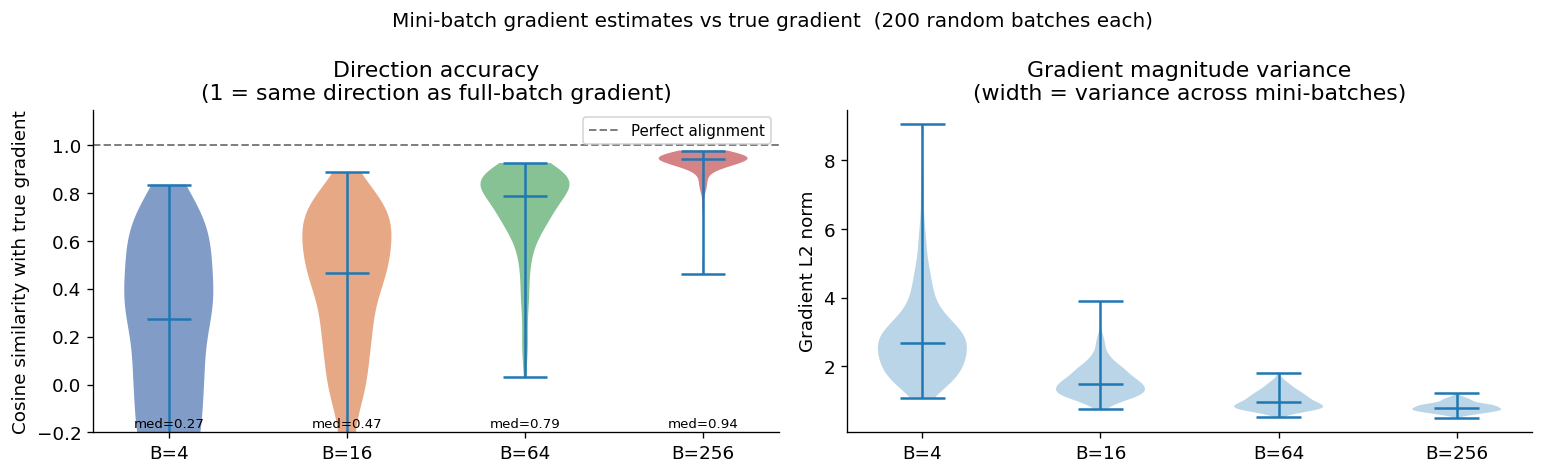

Cosine similarity (median ± std):
  B=   4:  0.274 ± 0.364
  B=  16:  0.467 ± 0.306
  B=  64:  0.788 ± 0.185
  B= 256:  0.943 ± 0.068


In [9]:
# Mini-batch GD: gradient estimate variance across batch sizes
# The key insight is that smaller batches produce noisier gradient estimates.
# We demonstrate this DIRECTLY: compute many mini-batch gradient estimates
# and compare their distribution to the true (full-batch) gradient.

torch.manual_seed(42)
m_ref = make_mlp()

# True gradient: computed over the full training set
m_ref.train()
crit = nn.BCELoss()
loss_full = crit(m_ref(Xtr_t).squeeze(-1), ytr_t)
loss_full.backward()

# Flatten all weight gradients into one vector - the 'true' direction
true_grad = torch.cat([p.grad.detach().flatten() for p in m_ref.parameters()])

# For each batch size: sample 200 random mini-batches and record
# (a) cosine similarity with the true gradient  (b) L2 norm of the estimate
BATCH_SIZES  = [4, 16, 64, 256]
N_SAMPLES    = 200
cosine_sims  = {bs: [] for bs in BATCH_SIZES}
grad_norms   = {bs: [] for bs in BATCH_SIZES}

rng = torch.Generator().manual_seed(0)
for bs in BATCH_SIZES:
    for _ in range(N_SAMPLES):
        idx = torch.randperm(len(Xtr_t), generator=rng)[:bs]
        xb, yb = Xtr_t[idx], ytr_t[idx]

        m_ref.zero_grad()
        crit(m_ref(xb).squeeze(-1), yb).backward()
        g = torch.cat([p.grad.detach().flatten() for p in m_ref.parameters()])

        cos = torch.nn.functional.cosine_similarity(
            g.unsqueeze(0), true_grad.unsqueeze(0)).item()
        cosine_sims[bs].append(cos)
        grad_norms[bs].append(g.norm().item())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = [f'B={bs}' for bs in BATCH_SIZES]

# Left: cosine similarity distribution (violin)
parts = axes[0].violinplot([cosine_sims[bs] for bs in BATCH_SIZES],
                            positions=range(len(BATCH_SIZES)),
                            showmedians=True, showextrema=True)
for pc, c in zip(parts['bodies'], COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.7)
axes[0].set_xticks(range(len(BATCH_SIZES))); axes[0].set_xticklabels(labels)
axes[0].axhline(1.0, ls='--', color='gray', lw=1.2, label='Perfect alignment')
axes[0].set_ylabel('Cosine similarity with true gradient')
axes[0].set_title('Direction accuracy\n(1 = same direction as full-batch gradient)')
axes[0].set_ylim(-0.2, 1.15); axes[0].legend(fontsize=9)

# Right: gradient norm variance
axes[1].violinplot([grad_norms[bs] for bs in BATCH_SIZES],
                   positions=range(len(BATCH_SIZES)),
                   showmedians=True, showextrema=True)
for pc, c in zip(parts['bodies'], COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.7)
axes[1].set_xticks(range(len(BATCH_SIZES))); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Gradient L2 norm')
axes[1].set_title('Gradient magnitude variance\n(width = variance across mini-batches)')

for bs, x in zip(BATCH_SIZES, range(len(BATCH_SIZES))):
    med = np.median(cosine_sims[bs])
    axes[0].text(x, -0.18, f'med={med:.2f}', ha='center', fontsize=8)

plt.suptitle(
    'Mini-batch gradient estimates vs true gradient  '
    f'({N_SAMPLES} random batches each)',
    fontsize=12)
plt.tight_layout(); plt.show()

print('Cosine similarity (median ± std):')
for bs in BATCH_SIZES:
    cs = cosine_sims[bs]
    print(f'  B={bs:4d}:  {np.median(cs):.3f} ± {np.std(cs):.3f}')

**Що ми бачимо:**

**Ліворуч - точність напрямку:** косинусна схожість між градієнтом міні-батчу та справжнім градієнтом (по всіх даних). При B=4 напрямок дуже ненадійний (широкий розподіл, низька медіана). При B=256 - майже завжди збігається зі справжнім.

**Праворуч - дисперсія норми:** ширина скрипки показує, наскільки сильно «скаче» масштаб градієнта між різними батчами.

**Висновок:** менший батч → гірша оцінка напрямку та масштабу градієнта → «шумніший» крок оновлення. Але цей шум має і позитивний бік - він допомагає виходити із локальних мінімумів і сідлових точок (про це - в наступному розділі).

**Практичне правило:** при збільшенні batch size у $k$ разів зазвичай збільшують learning rate у $\sqrt{k}$ або $k$ разів (linear scaling rule).

---

## 2. Проблеми ванільного SGD <a id="2"></a>

Чому SGD з фіксованим LR недостатній? Три головні проблеми:

| Проблема | Опис |
|---|---|
| **Ущелина (ravine)** | Різна кривизна вздовж різних напрямків → осциляції |
| **Сідлова точка** | $\|\nabla\mathcal{L}\| \approx 0$, але це не мінімум |
| **Однаковий LR** | Усі параметри оновлюються з тим самим $\eta$ |

Нижче - демонстрації кожної проблеми на інтерактивних прикладах.

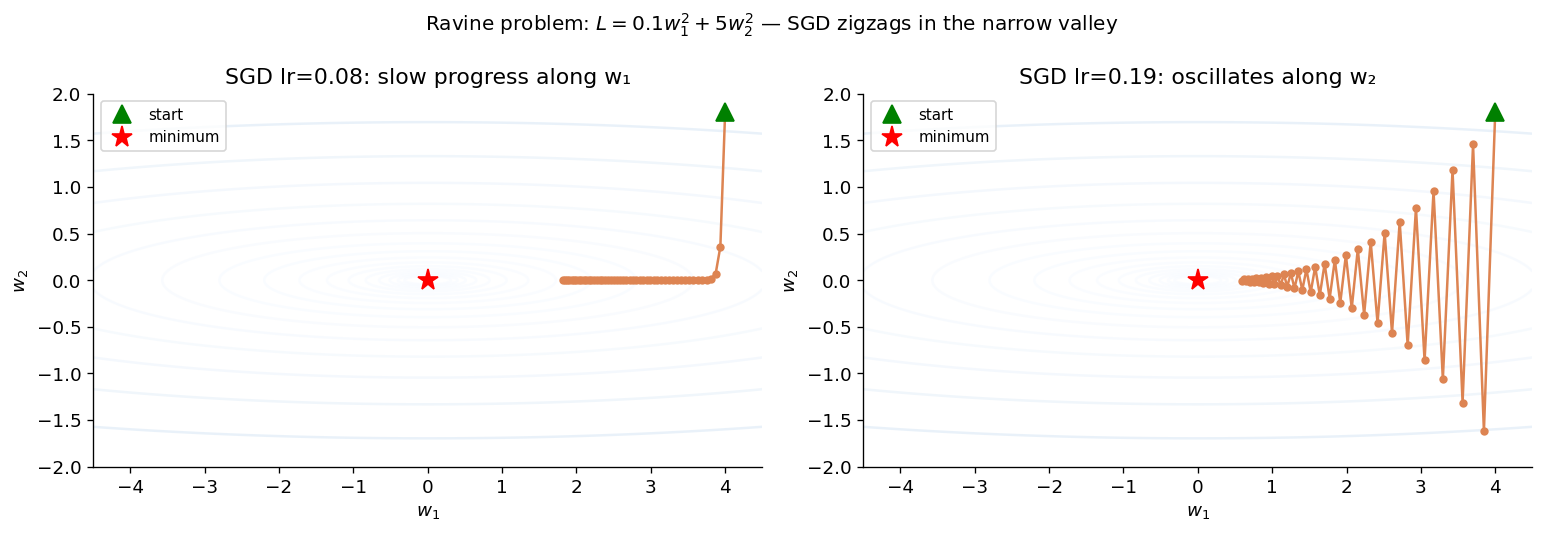

In [10]:
# Ill-conditioned surface: L(w1, w2) = 0.1*w1^2 + 5*w2^2
# High curvature along w2, low along w1 - classic ravine

w1 = np.linspace(-4.5, 4.5, 300)
w2 = np.linspace(-2.0, 2.0, 300)
W1, W2 = np.meshgrid(w1, w2)
Z_rav = 0.1 * W1**2 + 5 * W2**2

def grad_ravine(w): return np.array([0.2*w[0], 10*w[1]])

def sgd_path(start, lr, n):
    w, path = np.array(start, float), []
    for _ in range(n):
        path.append(w.copy()); w -= lr * grad_ravine(w)
    return np.array(path)

path_ok   = sgd_path([4.0, 1.8], lr=0.08, n=50)
path_fast = sgd_path([4.0, 1.8], lr=0.19, n=50)   # too aggressive → diverges on w2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, path, title in zip(axes, [path_ok, path_fast],
        ['SGD lr=0.08: slow progress along w₁',
         'SGD lr=0.19: oscillates along w₂']):
    lvls = np.logspace(-2, 2, 20)
    ax.contour(W1, W2, Z_rav, levels=lvls, cmap='Blues', alpha=0.6)
    ax.plot(path[:, 0], path[:, 1], 'o-', color=COLORS[1], ms=4, lw=1.5)
    ax.plot(*path[0],  '^', ms=11, color='green', label='start')
    ax.plot(0, 0,      '*', ms=13, color='red',   label='minimum')
    ax.set_title(title); ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')
    ax.legend(fontsize=9)

plt.suptitle('Ravine problem: $L = 0.1w_1^2 + 5w_2^2$ - SGD zigzags in the narrow valley',
             fontsize=12)
plt.tight_layout(); plt.show()

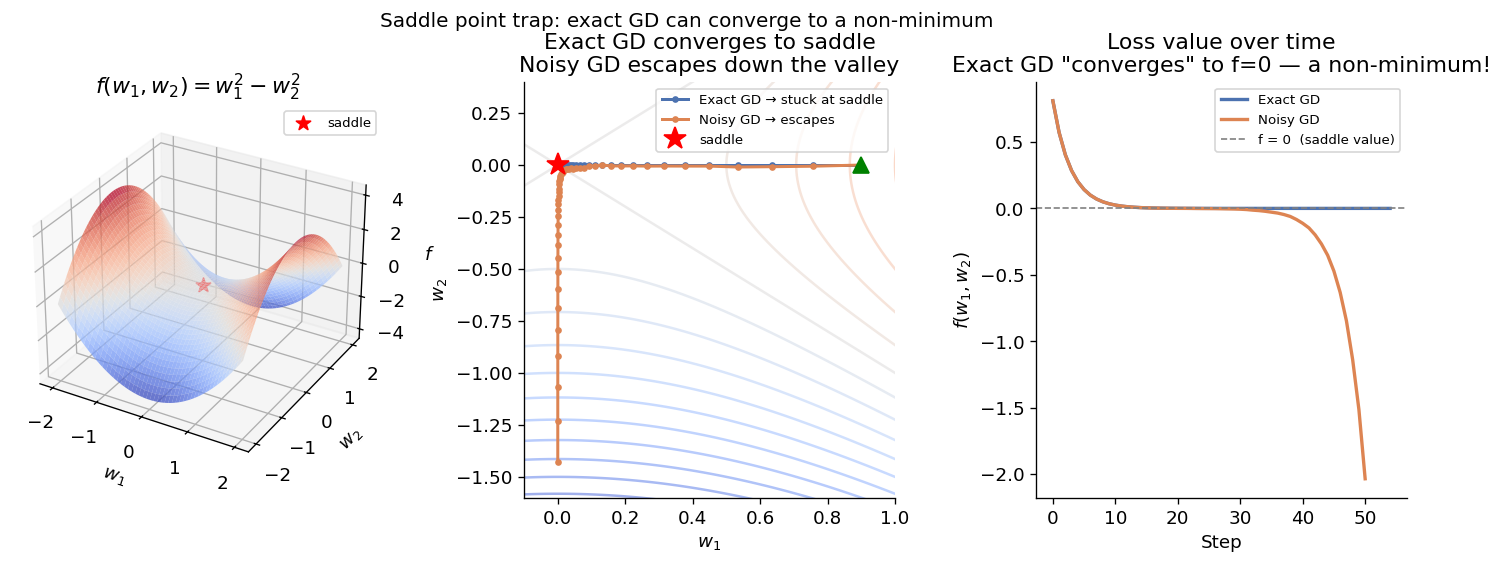

In [11]:
N  = 55
LR = 0.08

def grad_saddle(w): return np.array([2*w[0], -2*w[1]])

# Exact GD - starts on w2=0, w1 shrinks to 0, w2 stays 0 forever
# → converges TO the saddle (a non-minimum!)
path_gd, norms_gd, loss_gd = [], [], []
ws = np.array([0.9, 0.0])
for _ in range(N):
    path_gd.append(ws.copy())
    g = grad_saddle(ws)
    norms_gd.append(np.linalg.norm(g))
    loss_gd.append(ws[0]**2 - ws[1]**2)
    ws = ws - LR * g
path_gd = np.array(path_gd)

# Noisy GD - tiny noise in w2 breaks symmetry → escapes down the valley
np.random.seed(3)
path_noisy, norms_noisy, loss_noisy = [], [], []
ws = np.array([0.9, 0.0])
for _ in range(N):
    path_noisy.append(ws.copy())
    g = grad_saddle(ws) + np.array([0.0, np.random.normal(0, 0.04)])
    norms_noisy.append(np.linalg.norm(g))
    loss_noisy.append(ws[0]**2 - ws[1]**2)
    ws = ws - LR * g
path_noisy = np.array(path_noisy)

# Clip noisy path display once it flies off
clip = next((i for i, p in enumerate(path_noisy) if abs(p[1]) > 1.5), N)

fig = plt.figure(figsize=(15, 4.5))
gs  = fig.add_gridspec(1, 3, wspace=0.38)

# --- 3D surface ---
w   = np.linspace(-2.0, 2.0, 200)
W1s, W2s = np.meshgrid(w, w)
Z_sad    = W1s**2 - W2s**2
ax3 = fig.add_subplot(gs[0], projection='3d')
ax3.plot_surface(W1s, W2s, Z_sad, cmap='coolwarm', alpha=0.75, linewidth=0)
ax3.scatter(0, 0, 0, color='red', s=80, marker='*', zorder=5, label='saddle')
ax3.set_title('$f(w_1,w_2)=w_1^2-w_2^2$')
ax3.set_xlabel('$w_1$'); ax3.set_ylabel('$w_2$'); ax3.set_zlabel('$f$')
ax3.legend(fontsize=8)

# --- Trajectory top-view ---
ax2 = fig.add_subplot(gs[1])
ax2.contour(W1s, W2s, Z_sad, levels=np.linspace(-3, 3, 25),
            cmap='coolwarm', alpha=0.55)
ax2.plot(path_gd[:, 0],         path_gd[:, 1],         '-o',
         color=COLORS[0], lw=1.8, ms=3, label='Exact GD → stuck at saddle')
ax2.plot(path_noisy[:clip, 0],  path_noisy[:clip, 1],  '-o',
         color=COLORS[1], lw=1.8, ms=3, label='Noisy GD → escapes')
ax2.plot(*path_gd[0],  '^', ms=10, color='green')
ax2.plot(0, 0, '*', ms=14, color='red', zorder=5, label='saddle')
ax2.set_xlim(-0.1, 1.0); ax2.set_ylim(-1.6, 0.4)
ax2.set_xlabel('$w_1$'); ax2.set_ylabel('$w_2$')
ax2.set_title('Exact GD converges to saddle\nNoisy GD escapes down the valley')
ax2.legend(fontsize=8)

# --- Loss over time ---
ax3b = fig.add_subplot(gs[2])
ax3b.plot(loss_gd,            color=COLORS[0], lw=2, label='Exact GD')
ax3b.plot(loss_noisy[:clip],  color=COLORS[1], lw=2, label='Noisy GD')
ax3b.axhline(0, color='gray', ls='--', lw=1, label='f = 0  (saddle value)')
ax3b.set_xlabel('Step'); ax3b.set_ylabel('$f(w_1, w_2)$')
ax3b.set_title('Loss value over time\nExact GD "converges" to f=0 - a non-minimum!')
ax3b.legend(fontsize=8)

plt.suptitle('Saddle point trap: exact GD can converge to a non-minimum',
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

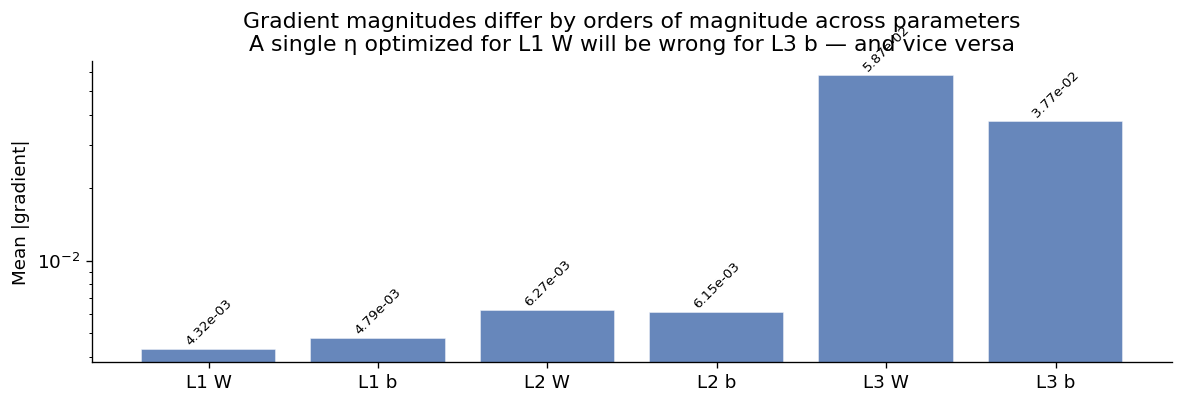

Largest / smallest mean gradient: 13.6×
→ Adaptive methods (RMSProp, Adam) assign a separate effective LR per parameter.


In [12]:
# Same LR for all parameters: the problem
# Different parameters receive gradients of very different magnitudes.
# A single η that works for one will be too large or too small for another.

torch.manual_seed(42)
m_demo = make_mlp()
crit   = nn.BCELoss()
m_demo.train()
crit(m_demo(Xtr_t).squeeze(-1), ytr_t).backward()

# Collect per-parameter gradient statistics
param_labels, grad_means = [], []
for name, p in m_demo.named_parameters():
    if p.grad is not None:
        grad_means.append(p.grad.abs().mean().item())
        # Shorten label: "0.weight" → "L1 W", "0.bias" → "L1 b"
        parts = name.split('.')
        layer = int(parts[0]) // 2 + 1   # every 2 modules = one Linear
        kind  = 'W' if parts[1] == 'weight' else 'b'
        param_labels.append(f'L{layer} {kind}')

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(param_labels, grad_means, color=COLORS[0], edgecolor='white', alpha=0.85)
for bar, v in zip(bars, grad_means):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.04,
            f'{v:.2e}', ha='center', fontsize=8, rotation=45)

ax.set_ylabel('Mean |gradient|')
ax.set_title(
    'Gradient magnitudes differ by orders of magnitude across parameters\n'
    'A single η optimized for L1 W will be wrong for L3 b - and vice versa')
ax.set_yscale('log')
plt.tight_layout(); plt.show()

ratio = max(grad_means) / min(grad_means)
print(f'Largest / smallest mean gradient: {ratio:.1f}×')
print('→ Adaptive methods (RMSProp, Adam) assign a separate effective LR per parameter.')

**Висновок:** ванільний SGD:
- Осцилює в ущелинах і не може одночасно мати великий крок у "широких" та малий у "вузьких" напрямках
- Застряє поблизу сідлових точок через малий градієнт
- Використовує один і той самий $\eta$ для всіх параметрів

Усі наступні методи вирішують ці проблеми різними способами.

---

## 3. Momentum та Nesterov <a id="3"></a>

### 3.0 Експоненційно зважене середнє (EWA)

Перед тим як розглядати momentum, варто зрозуміти базовий інструмент, на якому він побудований.

**Експоненційно зважене середнє** послідовності $x_1, x_2, \ldots$ визначається рекурентно:

$$\boxed{v_t = \beta\, v_{t-1} + (1 - \beta)\, x_t}$$

де $\beta \in [0, 1)$ - коефіцієнт згладжування. Розкриваючи рекурсію:

$$v_t = (1-\beta)\sum_{k=0}^{t-1} \beta^k\, x_{t-k}$$

Ваги спадають **експоненційно** в минуле - давні значення майже не впливають на $v_t$.

| $\beta$ | Ефективне вікно $\approx \frac{1}{1-\beta}$ | Поведінка |
|---|---|---|
| 0.5 | 2 кроки | дуже реактивне, мало пам'яті |
| 0.9 | 10 кроків | стандартний вибір |
| 0.99 | 100 кроків | гладке, але повільно реагує |

> 💡 EWA з'явиться двічі в Adam: як перший момент (напрямок) і як другий момент (масштаб).



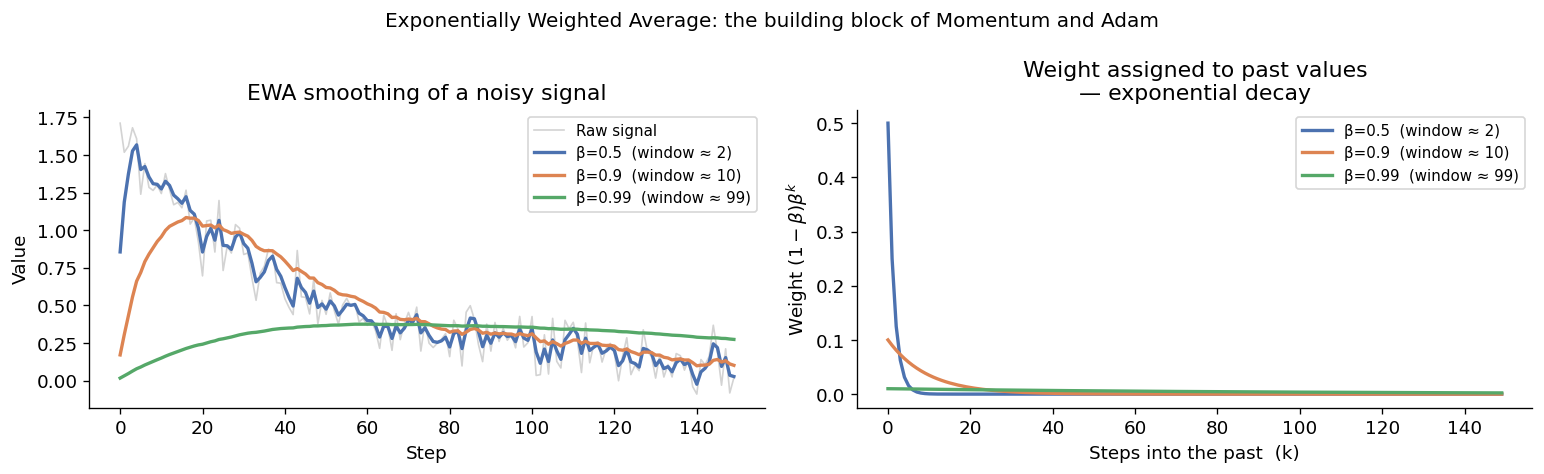

In [13]:
# Exponentially weighted average - visualizing the smoothing effect
# Input: noisy signal (simulated loss values)
np.random.seed(0)
T      = 150
signal = 1.5 * np.exp(-np.linspace(0, 3, T)) + np.random.normal(0, 0.12, T)

def ewa(x, beta):
    v, out = 0.0, []
    for xi in x:
        v = beta * v + (1 - beta) * xi
        out.append(v)
    return np.array(out)

betas  = [0.5, 0.9, 0.99]
labels = [f'β={b}  (window ≈ {int(1/(1-b))})'  for b in betas]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: smoothed signals overlaid on raw
axes[0].plot(signal, color='lightgray', lw=1, label='Raw signal')
for b, lbl, c in zip(betas, labels, COLORS):
    axes[0].plot(ewa(signal, b), lw=2, color=c, label=lbl)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Value')
axes[0].set_title('EWA smoothing of a noisy signal')
axes[0].legend(fontsize=9)

# Right: weight assigned to past values  w_k = (1-β) * β^k
K = np.arange(150)
for b, lbl, c in zip(betas, labels, COLORS):
    weights = (1 - b) * b ** K
    axes[1].plot(K, weights, lw=2, color=c, label=lbl)
axes[1].set_xlabel('Steps into the past  (k)'); axes[1].set_ylabel('Weight $(1-\\beta)\\beta^k$')
axes[1].set_title('Weight assigned to past values\n- exponential decay')
axes[1].legend(fontsize=9)

plt.suptitle('Exponentially Weighted Average: the building block of Momentum and Adam',
             fontsize=12)
plt.tight_layout(); plt.show()

**Як читати ці графіки:**

**Ліворуч** - один і той самий шумний сигнал, згладжений з різними $\beta$. При $\beta=0.5$ крива майже повторює оригінал - кожне нове значення має велику вагу $(1-\beta)=0.5$, тому EWA швидко реагує на зміни, але зберігає шум. При $\beta=0.99$ крива дуже гладка, але *запізнюється* - вона «пам'ятає» останні ~100 кроків і повільно адаптується до нових значень.

**Праворуч** - скільки ваги отримує кожен минулий крок. При $\beta=0.5$ вага вже через 5 кроків практично нульова: модель «забуває» минуле дуже швидко. При $\beta=0.99$ хвіст довгий - події 50–70 кроків тому ще суттєво впливають на поточне значення $v_t$.

**Зв'язок з momentum:** у SGD з імпульсом $x_t = \nabla\mathcal{L}$ - поточний градієнт. $v_t$ акумулює *напрямок руху*: якщо градієнти кілька кроків підряд вказують в один бік, $v_t$ посилює цей напрямок; якщо градієнти осцилюють - вони взаємно гасяться.

### 3.1 SGD з імпульсом (Classical Momentum)

**Ідея:** накопичувати *імпульс* - експоненційно зважену суму попередніх градієнтів.

$$\boxed{v_t = \beta \, v_{t-1} + \nabla_\theta \mathcal{L}(\theta_t)}$$
$$\boxed{\theta_{t+1} = \theta_t - \eta \, v_t}$$

де $\beta \in [0.8, 0.99]$ - коефіцієнт імпульсу (зазвичай $\beta = 0.9$).

**Фізична аналогія:** куля, що котиться по схилу - прискорюється вздовж нахилу, гасить коливання в перпендикулярному напрямку.

| $\beta$ | Поведінка |
|---|---|
| 0 | звичайний SGD |
| 0.9 | стандартний вибір |
| → 1 | довга "пам'ять", може перестрибнути мінімум |

### 3.2 Nesterov Accelerated Gradient (NAG)

**Проблема momentum:** градієнт рахується в поточній позиції $\theta_t$, а рухаємось ми далеко вперед. Чи не краще рахувати градієнт там, куди *збираємось* потрапити?

$$\boxed{v_t = \beta \, v_{t-1} + \nabla_\theta \mathcal{L}(\theta_t - \eta \beta \, v_{t-1})}$$
$$\boxed{\theta_{t+1} = \theta_t - \eta \, v_t}$$

Спочатку "дивимось вперед" на $\theta_t - \eta\beta v_{t-1}$, рахуємо там градієнт, і лише потім оновлюємо.

> 💡 У PyTorch: `optim.SGD(params, lr=lr, momentum=0.9, nesterov=True)`

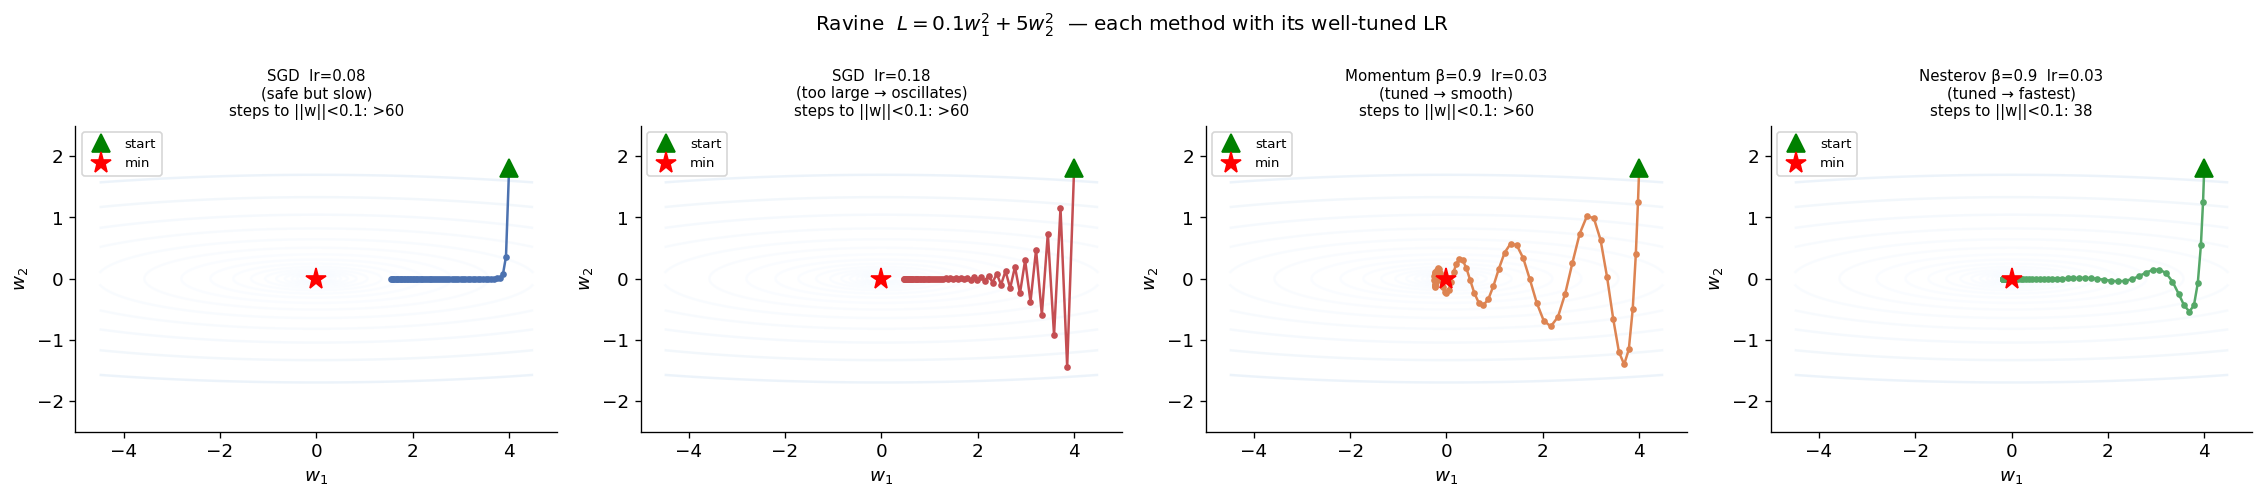

In [14]:
# Trajectory comparison on the ravine: SGD vs Momentum vs Nesterov
# Each method uses its own well-tuned LR (fair comparison).
# Fourth panel: SGD with a large LR - shows the oscillation problem momentum solves.

def momentum_path(start, lr, beta, n, nesterov=False):
    w, v, path = np.array(start, float), np.zeros(2), []
    for _ in range(n):
        path.append(w.copy())
        g = grad_ravine(w - lr * beta * v) if nesterov else grad_ravine(w)
        v = beta * v + g
        w -= lr * v
    return np.array(path)

START, N = [4.0, 1.8], 60

paths = {
    'SGD  lr=0.08\n(safe but slow)':             (sgd_path(START, 0.08, N),  COLORS[0]),
    'SGD  lr=0.18\n(too large → oscillates)':    (sgd_path(START, 0.18, N),  COLORS[3]),
    'Momentum β=0.9  lr=0.03\n(tuned → smooth)': (momentum_path(START, 0.03, 0.9, N), COLORS[1]),
    'Nesterov β=0.9  lr=0.03\n(tuned → fastest)':(momentum_path(START, 0.03, 0.9, N, nesterov=True), COLORS[2]),
}

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
lvls = np.logspace(-2, 2, 20)

for ax, (name, (path, color)) in zip(axes, paths.items()):
    ax.contour(W1, W2, Z_rav, levels=lvls, cmap='Blues', alpha=0.5)
    # clip display if path flies off
    clip = next((i for i, p in enumerate(path) if np.linalg.norm(p) > 6), len(path))
    ax.plot(path[:clip, 0], path[:clip, 1], 'o-', color=color, ms=3, lw=1.5)
    ax.plot(*path[0], '^', ms=11, color='green', label='start')
    ax.plot(0, 0,    '*', ms=13, color='red',   label='min')
    steps = next((i for i, p in enumerate(path) if np.linalg.norm(p) < 0.1), N)
    steps_str = str(steps) if steps < N else f'>{N}'
    ax.set_title(f'{name}\nsteps to ||w||<0.1: {steps_str}', fontsize=9)
    ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')
    ax.set_xlim(-5, 5); ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=8)

plt.suptitle('Ravine  $L = 0.1w_1^2 + 5w_2^2$  - each method with its well-tuned LR',
             fontsize=12)
plt.tight_layout(); plt.show()

**Що показують траєкторії:**

**SGD lr=0.08 (safe):** пряма траєкторія без осциляцій - але тільки тому, що LR свідомо малий. Кривизна вздовж $ у 50 разів більша, ніж вздовж $, тому будь-який LR, достатній для швидкого руху по $, вже небезпечний по $.

**SGD lr=0.18 (too large):** той самий SGD з LR, більшим у 2×. Тепер він осцилює по $ і навіть розходиться - саме ця поведінка обмежує SGD на погано обумовлених поверхнях.

**Momentum lr=0.03 (tuned):** менший LR, ніж у SGD, але накопичений імпульс компенсує це прискоренням вздовж $. Траєкторія гладка, і конвергенція швидша. *Важливо:* momentum підсилює кроки в усіх напрямках, тому йому потрібен менший LR, ніж SGD - інакше отримаємо панель 2.

**Nesterov lr=0.03 (tuned):** ті самі гіперпараметри, але помітно менше кроків. Завдяки «випереджувальному» градієнту Nesterov починає гальмувати раніше, не чекаючи, поки імпульс вже «перелетів» мінімум.

> 💡 **Практичний висновок:** при переході від SGD до Momentum/Nesterov - зменшіть LR приблизно у 2–3 рази як стартову точку. Nesterov є розумним значенням за замовчуванням: він майже ніколи не гірший за класичний momentum.

---

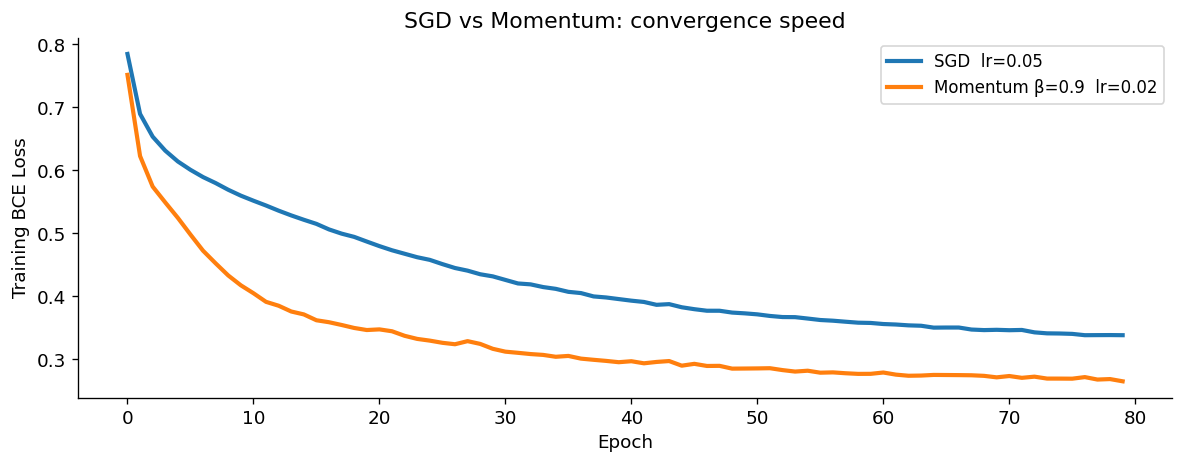

In [15]:
# SGD vs Momentum: convergence speed on the classification dataset.

def make_small_mlp():
    m = nn.Sequential(
        nn.Linear(20, 16), nn.ReLU(),
        nn.Linear(16, 1),  nn.Sigmoid()
    ).to(DEVICE)
    for layer in m:
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
    return m

configs_mom = [
    ('SGD  lr=0.05',       optim.SGD, dict(lr=0.05)),
    ('Momentum β=0.9  lr=0.02', optim.SGD, dict(lr=0.02, momentum=0.9)),
]

fig, ax = plt.subplots(figsize=(10, 4))
for name, Opt, kw in configs_mom:
    torch.manual_seed(42)
    m  = make_small_mlp()
    tr, _, _ = train_model(m, Opt(m.parameters(), **kw),
                            train_loader, Xval_t, yval_t, n_epochs=80)
    ax.plot(tr, label=name, lw=2.5)

ax.set_xlabel('Epoch'); ax.set_ylabel('Training BCE Loss')
ax.set_title(
    'SGD vs Momentum: convergence speed')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

Як бачимо, Momentum суттєво пришвидшує збіжність.

---

## 4. RMSProp → Adam → AdamW <a id="4"></a>

### 4.1 Мотивація: AdaGrad і його проблема

**AdaGrad** (Duchi et al., 2011) відповідає на питання: *чому всі параметри повинні оновлюватись з однаковим $\eta$?*

**Ключова ідея:** параметр, який отримував великі градієнти в минулому, вже «багато навчився» - йому потрібен менший крок. Параметр з малими градієнтами (рідкісна ознака, мало активна) навпаки - потребує більшого кроку щоб наздогнати.

**Механізм:** для кожного параметра $\theta_j$ накопичуємо суму квадратів усіх його градієнтів від початку навчання:

$$G_t^{(j)} = G_{t-1}^{(j)} + \left(\frac{\partial \mathcal{L}}{\partial \theta_j}\right)^2 $$

$G_t^{(j)}$ - це **«історія активності»** параметра $j$: акумульована сума квадратів усіх його градієнтів від кроку 1 до $t$. Вона тільки зростає і ніколи не зменшується.

Ефективний learning rate для параметра $j$ на кроці $t$:

$$\eta_t^{(j)} = \frac{\eta}{\sqrt{G_t^{(j)} + \varepsilon}}$$

Повне оновлення (поелементно для всіх параметрів одночасно):

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \varepsilon}}\,\nabla_\theta \mathcal{L}$$

| Параметр | $G_t$ | Ефективний LR |
|---|---|---|
| Часто активний, великі градієнти | великий | малий - «гальмуємо» |
| Рідко активний, малі градієнти | малий | великий - «прискорюємо» |

**Чому $\varepsilon$?** Захист від ділення на нуль, якщо параметр ще не отримав жодного градієнта. Зазвичай $\varepsilon = 10^{-8}$.

**Проблема:** $G_t$ є *монотонно зростаючою* сумою - вона ніколи не зменшується. Через достатньо велику кількість кроків $\eta / \sqrt{G_t} \to 0$ для **всіх** параметрів, і навчання «замерзає» - незалежно від того, чи ще є куди рости.


### 4.2 RMSProp

**RMSProp** (Hinton, 2012) виправляє це через *експоненційно зважене середнє* квадратів градієнтів:

$$\boxed{s_t = \rho\,s_{t-1} + (1-\rho)(\nabla_\theta \mathcal{L})^2}$$
$$\boxed{\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t + \varepsilon}}\,\nabla_\theta \mathcal{L}}$$

де $\rho \approx 0.9$, $\varepsilon \approx 10^{-8}$. Параметри з великими градієнтами отримують менший ефективний LR, і навпаки.

### 4.3 Adam (Kingma & Ba, 2015)

**Adam = Momentum + RMSProp + корекція зсуву**

Adam одночасно відстежує **два окремих EWA для кожного параметра**. Щоб зрозуміти навіщо - згадаємо, що нам потрібно від оптимізатора:

1. **Правильний напрямок кроку** - не шумний поточний градієнт, а згладжена оцінка «куди ми йдемо». Це дає Momentum.
2. **Правильний масштаб кроку** - різні параметри мають різні масштаби градієнтів, потрібен адаптивний LR. Це дає RMSProp.

Adam вирішує обидві задачі одночасно через два буфери.

---

**Перший момент $m_t$ - EWA градієнтів («куди рухатись»)**

Це те саме, що momentum: згладжена оцінка *очікуваного значення* градієнта $\mathbb{E}[g_t]$. Замість шумного поточного кроку використовуємо усереднений напрямок за останні кроки:

$$\boxed{m_t = \beta_1 m_{t-1} + (1-\beta_1)\,g_t}$$

де $g_t = \nabla_\theta \mathcal{L}$. При $\beta_1 = 0.9$ ефективне вікно - останні ~10 кроків.

---

**Другий момент $v_t$ - EWA квадратів градієнтів («наскільки великий крок»)**

Це те саме, що RMSProp: згладжена оцінка *дисперсії* градієнта $\mathbb{E}[g_t^2]$. Великий $v_t$ означає, що градієнти цього параметра були стабільно великими - треба гальмувати. Малий $v_t$ - можна робити більший крок:

$$\boxed{v_t = \beta_2 v_{t-1} + (1-\beta_2)\,g_t^2}$$

При $\beta_2 = 0.999$ вікно значно ширше (~1000 кроків) - масштаб змінюється повільніше, ніж напрямок.

---

**Bias correction - навіщо ділити на $(1-\beta^t)$?**

Проблема: обидва буфери ініціалізуються нулем ($m_0 = v_0 = 0$). На перших кроках вони *занижені* - EWA ще не встиг «прогрітися». Наприклад, на кроці $t=1$:
$$m_1 = \beta_1 \cdot 0 + (1-\beta_1) g_1 = 0.1\, g_1 \quad \ll \quad g_1$$

Корекція зсуву ділить на частку, що вже «накопичилась», повертаючи правильний масштаб:

$$\boxed{\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}}$$

При великих $t$: $\beta^t \to 0$, тому $\hat{m}_t \approx m_t$ - корекція стає непомітною. Вона важлива лише на початку навчання.

---

**Фінальне оновлення:**

$$\boxed{\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t}+\varepsilon}\,\hat{m}_t}$$

Читається як: *зроби крок у згладженому напрямку $\hat{m}_t$, але масштабуй його обернено до типового розміру градієнта $\sqrt{\hat{v}_t}$.*

Якщо градієнти стабільно великі ($\sqrt{\hat{v}_t}$ великий) - крок малий. Якщо градієнти малі або непостійні ($\sqrt{\hat{v}_t}$ малий) - крок великий. Ефективний LR для кожного параметра автоматично адаптується.

| Гіперпараметр | Типове значення | Роль |
|---|---|---|
| $\eta$ | 0.001 | базовий learning rate |
| $\beta_1$ | 0.9 | згладжування напрямку (вікно ~10 кроків) |
| $\beta_2$ | 0.999 | згладжування масштабу (вікно ~1000 кроків) |
| $\varepsilon$ | $10^{-8}$ | захист від ділення на нуль |

> 💡 **Чому Adam такий популярний?** Він майже не потребує підбору LR - значення $\eta = 10^{-3}$ працює «з коробки» для більшості задач. SGD з momentum при тих самих результатах потребує ретельного підбору LR і schedule.

### 4.4 AdamW: правильний weight decay

**Проблема: Adam + L2 ≠ weight decay**

Здавалося б, достатньо додати L2-регуляризацію до функції втрат:
$$\mathcal{L}_{reg} = \mathcal{L} + \frac{\lambda}{2}\|\theta\|^2$$

Тоді градієнт набуває додаткового члена $\lambda\theta$, і він потрапляє **всередину обох моментів** Adam:
$$m_t = \beta_1 m_{t-1} + (1-\beta_1)(g_t + \lambda\theta_t)$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2)(g_t + \lambda\theta_t)^2$$

Це означає, що регуляризаційний член $\lambda\theta_t$ **адаптивно масштабується** через $\sqrt{\hat{v}_t}$ - так само, як і градієнт. Параметри з великими градієнтами отримують менший штраф за розмір, ніж параметри з малими градієнтами. Це порушує сенс L2-регуляризації: ми хотіли рівномірно штрафувати *всі* великі ваги, а отримуємо нерівномірне штрафування залежно від історії градієнтів.

**Рішення: decoupled weight decay (AdamW)**

(Loshchilov & Hutter, 2019) пропонують виконувати weight decay **після** адаптивного кроку Adam, прямо на вазі - незалежно від градієнта:

$$\boxed{\theta_{t+1} = \underbrace{\theta_t - \frac{\eta\,\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon}}_{\text{Adam step}} - \underbrace{\eta\lambda\,\theta_t}_{\text{weight decay}}}$$

Тепер $\lambda\theta_t$ не залежить від $\hat{v}_t$ - кожна вага штрафується пропорційно своєму поточному значенню, як і задумувалось. Ефективний LR для градієнтного кроку і для weight decay більше не змішуються.

> 💡 `optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)`  
> Типові значення `weight_decay`: $10^{-4}$–$10^{-1}$ залежно від ступеня регуляризації.

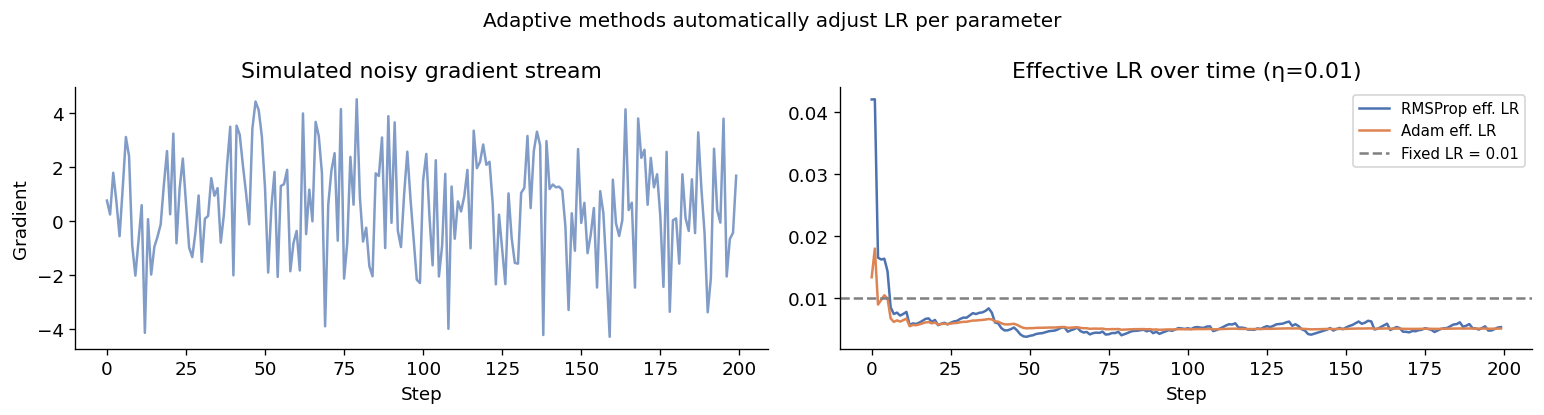

In [16]:
# Visualize adaptive LR: how per-parameter effective LR evolves
n_steps = 200
rng     = np.random.default_rng(0)
grads   = rng.normal(0.5, 2.0, n_steps)   # noisy gradient stream

# RMSProp effective LR
s, rho, eps = 0.0, 0.9, 1e-8
rmsprop_lr  = []
for g in grads:
    s = rho * s + (1 - rho) * g**2
    rmsprop_lr.append(0.01 / np.sqrt(s + eps))

# Adam effective LR
ma, va, b1, b2 = 0.0, 0.0, 0.9, 0.999
adam_lr = []
for t, g in enumerate(grads, 1):
    ma = b1 * ma + (1 - b1) * g
    va = b2 * va + (1 - b2) * g**2
    mh = ma / (1 - b1**t)
    vh = va / (1 - b2**t)
    adam_lr.append(0.01 / (np.sqrt(vh) + eps))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(grads, color=COLORS[0], alpha=0.7)
axes[0].set_title('Simulated noisy gradient stream')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Gradient')

axes[1].plot(rmsprop_lr, label='RMSProp eff. LR', color=COLORS[0], lw=1.5)
axes[1].plot(adam_lr,    label='Adam eff. LR',    color=COLORS[1], lw=1.5)
axes[1].axhline(0.01, ls='--', color='gray', lw=1.5, label='Fixed LR = 0.01')
axes[1].set_title('Effective LR over time (η=0.01)')
axes[1].set_xlabel('Step'); axes[1].legend(fontsize=9)

plt.suptitle('Adaptive methods automatically adjust LR per parameter', fontsize=12)
plt.tight_layout(); plt.show()

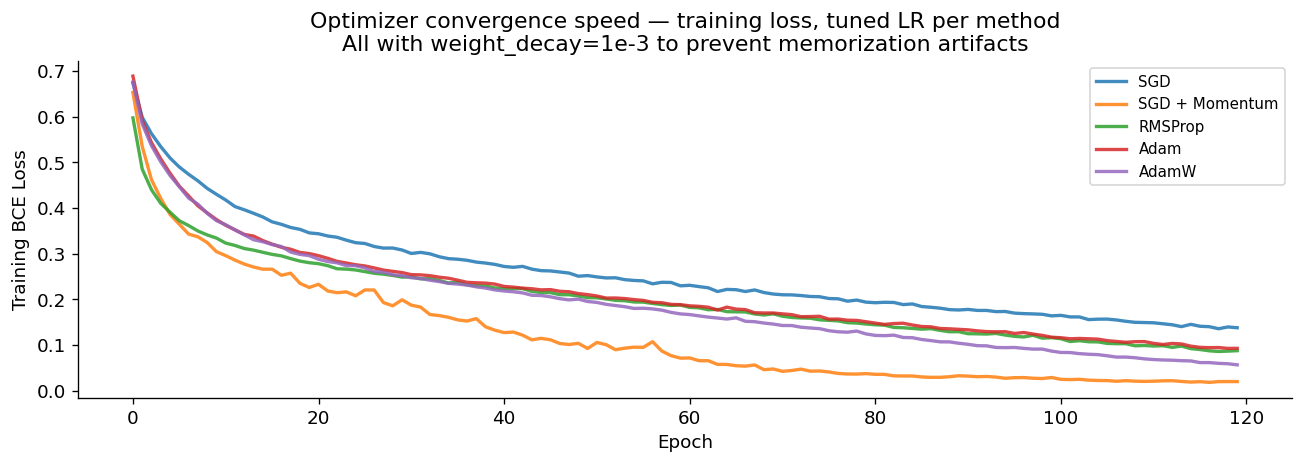

In [17]:
# Convergence comparison: all five optimizers.
# Goal: show SPEED OF DESCENT, not generalization.
# - Training loss only (val loss conflates optimizer choice with regularization)
# - Mild weight_decay=1e-3 for all to prevent memorization artifacts
# - Per-method tuned LR (consistent with the ravine demo lesson)
configs_opt = [
    ('SGD',            optim.SGD,     dict(lr=0.05,  weight_decay=1e-3)),
    ('SGD + Momentum', optim.SGD,     dict(lr=0.02,  momentum=0.9, weight_decay=1e-3)),
    ('RMSProp',        optim.RMSprop, dict(lr=1e-3,  weight_decay=1e-3)),
    ('Adam',           optim.Adam,    dict(lr=1e-3,  weight_decay=1e-3)),
    ('AdamW',          optim.AdamW,   dict(lr=1e-3,  weight_decay=1e-3)),
]

fig, ax = plt.subplots(figsize=(11, 4))

for name, Opt, kw in configs_opt:
    torch.manual_seed(42)
    m  = make_mlp()
    tr, _, _ = train_model(m, Opt(m.parameters(), **kw),
                            train_loader, Xval_t, yval_t, n_epochs=120)
    ax.plot(tr, label=name, lw=2, alpha=0.85)

ax.set_xlabel('Epoch'); ax.set_ylabel('Training BCE Loss')
ax.set_title(
    'Optimizer convergence speed - training loss, tuned LR per method\n'
    'All with weight_decay=1e-3 to prevent memorization artifacts')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. Learning Rate Scheduling <a id="5"></a>

**Проблема фіксованого LR:**
- Великий $\eta$ на початку: швидко наближаємось, але "перестрибуємо" мінімум
- Малий $\eta$ на кінці: точна збіжність, але надто повільний старт

**Рішення:** змінювати $\eta$ за заздалегідь визначеним розкладом.

### Основні стратегії

**StepLR** - зменшення в $\gamma$ разів кожні $s$ епох:
$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t/s \rfloor}$$

**ExponentialLR** - безперервне спадання:
$$\eta_t = \eta_0 \cdot \gamma^{t}$$

**CosineAnnealingLR** - плавне спадання за косинусом:
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\frac{\pi t}{T}\right)$$

**ReduceLROnPlateau** - зниження при відсутності прогресу val loss:
$$\text{якщо } \Delta\mathcal{L}_{val} < \text{tol впродовж patience епох:}\quad \eta \leftarrow \eta \cdot \text{factor}$$

**Warmup + CosineAnnealing** (популярно у Transformers):
$$\eta_t = \begin{cases} \frac{t}{T_{warm}} \cdot \eta_{\max} & t < T_{warm} \\ \eta_{\min} + \frac{1}{2}(\eta_{\max}-\eta_{\min})\left(1+\cos\frac{\pi(t-T_{warm})}{T-T_{warm}}\right) & t \geq T_{warm} \end{cases}$$

> 💡 Scheduler не залежить від типу оптимізатора - він просто оновлює `param_group['lr']`.

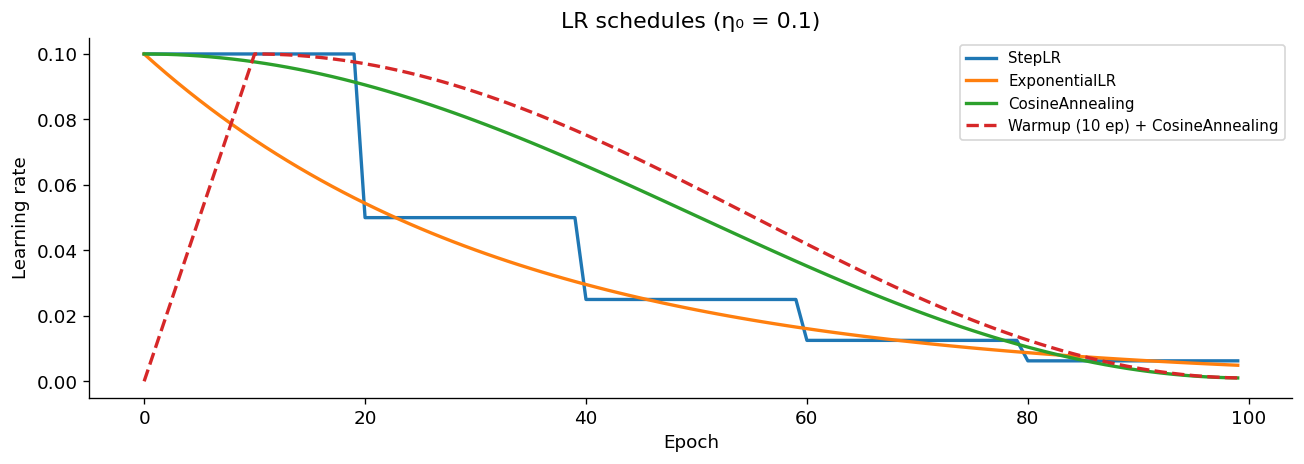

In [18]:
# Visualize LR schedules over 100 epochs
eta0, n_ep = 0.1, 100

def make_sched(name):
    p   = [nn.Parameter(torch.tensor(1.0))]
    opt = optim.SGD(p, lr=eta0)
    if name == 'StepLR':        return sched.StepLR(opt, step_size=20, gamma=0.5)
    if name == 'ExponentialLR': return sched.ExponentialLR(opt, gamma=0.97)
    if name == 'CosineAnnealing': return sched.CosineAnnealingLR(opt, T_max=n_ep, eta_min=1e-3)

def warmup_cosine(t, T_w=10, T=100, hi=0.1, lo=1e-3):
    if t < T_w: return hi * t / T_w
    prog = (t - T_w) / (T - T_w)
    return lo + 0.5 * (hi - lo) * (1 + np.cos(np.pi * prog))

fig, ax = plt.subplots(figsize=(11, 4))

for name in ['StepLR', 'ExponentialLR', 'CosineAnnealing']:
    sc, lrs = make_sched(name), []
    for _ in range(n_ep):
        lrs.append(sc.get_last_lr()[0]); sc.step()
    ax.plot(lrs, label=name, lw=2)

ax.plot([warmup_cosine(t) for t in range(n_ep)], '--',
        label='Warmup (10 ep) + CosineAnnealing', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate')
ax.set_title(f'LR schedules (η₀ = {eta0})')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---

## 6. Gradient Clipping <a id="6"></a>

### Проблема вибухаючих градієнтів

У глибоких мережах (особливо RNN) градієнти можуть зростати експоненційно через backprop через багато шарів.

### Clipping за нормою (рекомендовано)

$$\text{якщо } \|\mathbf{g}\|_2 > c: \quad \mathbf{g} \leftarrow \frac{c}{\|\mathbf{g}\|_2}\,\mathbf{g}$$

Напрямок градієнта зберігається - лише масштаб обмежується.

### Clipping за значенням (поелементно)

$$g_i \leftarrow \text{clip}(g_i,\; -c,\; +c)$$

Менш популярний: **змінює напрямок** градієнта.

```python
# PyTorch (після loss.backward(), до optimizer.step())
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

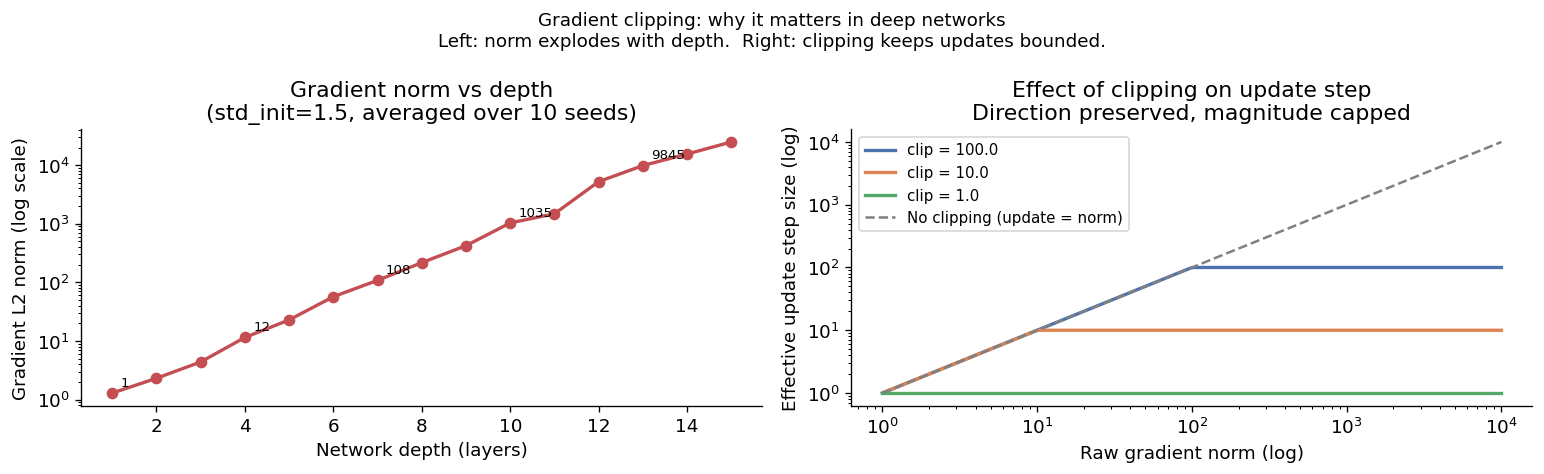

Gradient norm by depth:
  depth= 1:      1.3
  depth= 2:      2.3
  depth= 3:      4.4
  depth= 4:     11.5
  depth= 5:     22.9
  depth= 6:     57.0
  depth= 7:    108.4
  depth= 8:    217.1
  depth= 9:    423.5
  depth=10:   1034.6
  depth=11:   1481.1
  depth=12:   5243.7
  depth=13:   9845.3
  depth=14:  15487.8
  depth=15:  24884.4


In [30]:
# Gradient clipping demo.
# Standard MLPs rarely produce exploding gradients - we need to engineer the condition:
#   - Very deep network (10 layers) so gradients compound across many multiplications
#   - Large LR (2.0) so each update destabilizes weights further
#   - No BatchNorm, no weight decay
# This mimics what happens in deep RNNs / transformers without clipping.

def make_deep_mlp(depth=10, width=32):
    """Intentionally deep and unstable - for gradient explosion demo only."""
    layers = []
    sizes  = [20] + [width] * depth + [1]
    for i in range(len(sizes) - 1):
        lin = nn.Linear(sizes[i], sizes[i+1])
        nn.init.normal_(lin.weight, std=1.5)  # large init amplifies explosion
        layers.append(lin)
        if i < len(sizes) - 2:
            layers.append(nn.Tanh())           # tanh saturates, compounds vanishing/exploding
    layers.append(nn.Sigmoid())
    return nn.Sequential(*layers).to(DEVICE)

# Gradient explosion demo: norm as a function of DEPTH, not training time.
# The chain rule multiplies Jacobians across layers: ||dL/dh_0|| ≈ ∏||W_i|| * ||dL/dh_L||
# With ||W_i|| > 1 (large init), this grows exponentially with depth.
# This is why clipping matters in deep nets, RNNs, and Transformers.

DEPTHS   = list(range(1, 16))
N_TRIALS = 10   # average over random seeds to reduce variance

mean_norms = []
for depth in DEPTHS:
    trial_norms = []
    for seed in range(N_TRIALS):
        torch.manual_seed(seed)
        m = make_deep_mlp(depth=depth)
        m.train()
        crit = nn.BCELoss()
        crit(m(Xtr_t[:64]).squeeze(-1), ytr_t[:64]).backward()
        norm = sum(p.grad.norm(2).item()**2
                   for p in m.parameters() if p.grad is not None) ** 0.5
        trial_norms.append(norm)
    mean_norms.append(float(np.mean(trial_norms)))

# Effect of clipping on the update step at a given norm level
norms_range = np.logspace(0, 4, 200)
clip_values = [100.0, 10.0, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: gradient norm grows exponentially with depth
axes[0].plot(DEPTHS, mean_norms, 'o-', color=COLORS[3], lw=2)
axes[0].set_yscale('log')
axes[0].set_xlabel('Network depth (layers)')
axes[0].set_ylabel('Gradient L2 norm (log scale)')
axes[0].set_title(
    'Gradient norm vs depth\n'
    f'(std_init=1.5, averaged over {N_TRIALS} seeds)')
# Annotate approximate doubling
for d, n in zip(DEPTHS[::3], mean_norms[::3]):
    axes[0].annotate(f'{n:.0f}', (d, n), textcoords='offset points',
                     xytext=(5, 4), fontsize=8)

# Right: what clipping actually does to the update step
for clip, color in zip(clip_values, COLORS):
    effective = np.minimum(norms_range, clip) / norms_range  # scaling factor
    axes[1].plot(norms_range, effective * norms_range,
                 color=color, lw=2, label=f'clip = {clip}')
axes[1].plot(norms_range, norms_range, '--', color='gray', lw=1.5,
             label='No clipping (update = norm)')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Raw gradient norm (log)')
axes[1].set_ylabel('Effective update step size (log)')
axes[1].set_title('Effect of clipping on update step\nDirection preserved, magnitude capped')
axes[1].legend(fontsize=9)

plt.suptitle(
    'Gradient clipping: why it matters in deep networks\n'
    'Left: norm explodes with depth.  Right: clipping keeps updates bounded.',
    fontsize=11)
plt.tight_layout(); plt.show()

print('Gradient norm by depth:')
for d, n in zip(DEPTHS, mean_norms):
    print(f'  depth={d:2d}: {n:8.1f}')

**Як читати ці графіки:**

**Ліворуч - експоненційне зростання норми з глибиною.** При `std_init=1.5` кожен шар множить градієнт приблизно на константу, більшу за 1. За правилом ланцюжка:
$$\left\|\frac{\partial \mathcal{L}}{\partial h_0}\right\| \approx \prod_{i=1}^{L} \|W_i\| \cdot \left\|\frac{\partial \mathcal{L}}{\partial h_L}\right\|$$

Результат - майже ідеальна пряма на логарифмічній шкалі: глибина 1 → норма ~1, глибина 10 → ~1000, глибина 15 → ~25 000. Кожні 2–3 шари норма зростає на порядок.

**Праворуч - що кліпування фактично робить з кроком оновлення.** По осі X - «сире» значення градієнта, по осі Y - розмір кроку, який фактично робить оптимізатор. До порогу кліпування обидві криві збігаються (крок = норма). Після порогу крива «виходить на плато» - це і є ефект кліпування: **напрямок кроку зберігається, але його довжина обмежується константою**. Зверніть увагу: clip=1.0 (зелена) обмежує крок вже при нормі > 1, що приводить до повільного навчання.

> 💡 **Практичний висновок:** `clip_grad_norm_` з порогом 1.0–5.0 є стандартом для Transformer-моделей і RNN. Для звичайного MLP з помірним LR і He-ініціалізацією вибухаючі градієнти рідкісні - тому кліпування там зазвичай не потрібне.

## 7. L2-регуляризація та Weight Decay <a id="7"></a>

### Зв'язок з тижнем 2

На тижні 2 ми додавали L2-штраф до функції втрат логістичної регресії:

$$\mathcal{L}_{reg}(\theta) = \mathcal{L}(\theta) + \frac{\lambda}{2}\|\theta\|_2^2$$

Градієнт набуває додаткового члена $\lambda\theta$:
$$\nabla_\theta\mathcal{L}_{reg} = \nabla_\theta\mathcal{L} + \lambda\theta$$

Оновлення ваг стає:
$$\theta_{t+1} = \theta_t - \eta(\nabla_\theta\mathcal{L} + \lambda\theta_t) = \underbrace{(1-\eta\lambda)}_{\text{weight decay}}\theta_t - \eta\nabla_\theta\mathcal{L}$$

Коефіцієнт $(1-\eta\lambda)$ - це і є **weight decay**: ваги зменшуються на кожному кроці.

### У PyTorch

```python
# Recommended: decoupled weight decay via AdamW
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

# Alternative: manual L2 in the loss (as in Week 2)
l2 = sum(p.pow(2).sum() for p in model.parameters())
loss = criterion(pred, y) + 0.5 * lambda_ * l2
```

> ⚠️ Для `Adam` параметр `weight_decay` реалізує L2 **через градієнт** (масштабується адаптивно). Це гірше, ніж AdamW. Завжди використовуйте **AdamW** коли потрібна регуляризація.

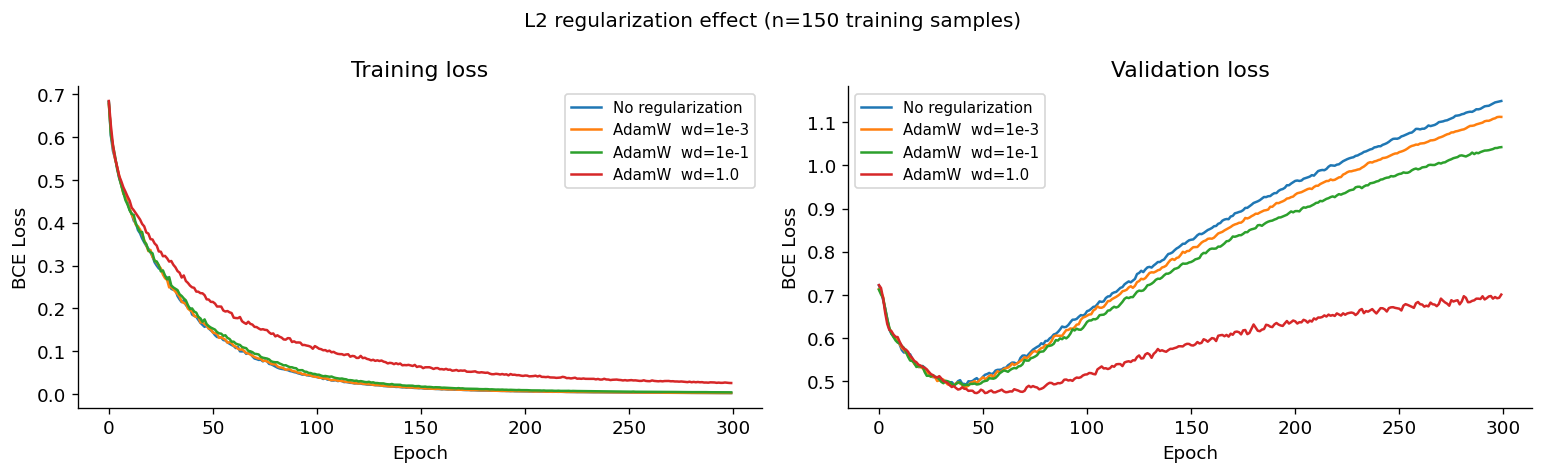

In [34]:
# Overfitting demo: 150 samples, wider range of weight_decay values
# to show clear separation between no/weak/strong regularization

configs_l2 = [
    ('No regularization',   optim.Adam,  dict(lr=1e-3)),
    ('AdamW  wd=1e-3',      optim.AdamW, dict(lr=1e-3, weight_decay=1e-3)),
    ('AdamW  wd=1e-1',      optim.AdamW, dict(lr=1e-3, weight_decay=1e-1)),
    ('AdamW  wd=1.0',       optim.AdamW, dict(lr=1e-3, weight_decay=1.0)),
]

Xs150, ys150 = Xtr_t[:150], ytr_t[:150]
loader150 = DataLoader(TensorDataset(Xs150, ys150), batch_size=32, shuffle=True,
                       generator=torch.Generator().manual_seed(42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, Opt, kw in configs_l2:
    torch.manual_seed(42)
    m   = make_mlp()
    tr, vl, _ = train_model(m, Opt(m.parameters(), **kw),
                             loader150, Xval_t, yval_t, n_epochs=300)
    axes[0].plot(tr, label=name)
    axes[1].plot(vl, label=name)

for ax, t in zip(axes, ['Training loss', 'Validation loss']):
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.set_title(t); ax.legend(fontsize=9)

plt.suptitle('L2 regularization effect (n=150 training samples)', fontsize=12)
plt.tight_layout(); plt.show()

**Що ми бачимо:** weight decay сповільнює зростання val loss, але не зупиняє його - модель з 150 прикладами все одно поступово запам'ятовує тренувальний набір. `wd=1.0` показує найкращу валідацію, але ціною вищого training loss - починається underfitting.

> 💡 Weight decay і early stopping є природними **доповненнями**, а не альтернативами. Weight decay обмежує складність моделі на кожному кроці; early stopping зупиняє навчання в найкращий момент. Разом вони дають набагато кращий результат - що ми побачимо в розділі 9.

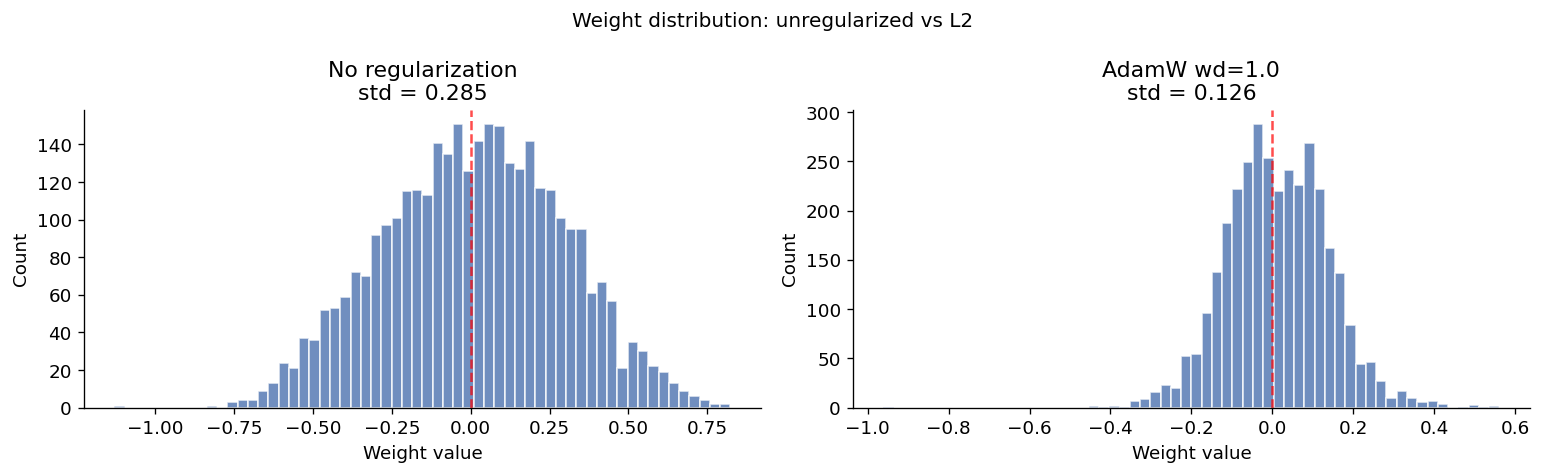

In [35]:
# Weight distribution: regularized vs unregularized
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, Opt, kw) in zip(axes, [
    ('No regularization',  optim.Adam,  dict(lr=1e-3)),
    ('AdamW wd=1.0',      optim.AdamW, dict(lr=1e-3, weight_decay=1.0)),
]):
    torch.manual_seed(42)
    m = make_mlp()
    train_model(m, Opt(m.parameters(), **kw), small_loader, Xval_t, yval_t, n_epochs=250)
    ws = np.concatenate([p.detach().cpu().numpy().ravel()
                         for p in m.parameters() if p.dim() > 1])
    ax.hist(ws, bins=60, color=COLORS[0], edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', ls='--', alpha=0.7)
    ax.set_title(f'{name}\nstd = {ws.std():.3f}')
    ax.set_xlabel('Weight value'); ax.set_ylabel('Count')

plt.suptitle('Weight distribution: unregularized vs L2', fontsize=12)
plt.tight_layout(); plt.show()

L2-регуляризація **стягує ваги до нуля** → менш "упевнена" модель → кращe узагальнення. Занадто великий `weight_decay` призводить до underfitting.

---

## 8. Dropout <a id="8"></a>

**Dropout** (Srivastava et al., 2014) під час тренування випадково "вимикає" нейрони з ймовірністю $p$.

### Inverted Dropout

Щоб масштаб активацій не змінювався між тренуванням та інференсом, застосовується **inverted dropout**:

$$\boxed{\tilde{a}_i = \frac{r_i \cdot a_i}{1-p}, \qquad r_i \sim \text{Bernoulli}(1-p)}$$

Ділення на $(1-p)$ зберігає **очікуване значення активації незмінним** - тому при `model.eval()` нічого не змінюється.

| Режим | Поведінка |
|---|---|
| `model.train()` | нейрони вимикаються з ймовірністю $p$ |
| `model.eval()` | **всі нейрони активні**, масштаб вже скоригований |

> ⚠️ **Типова помилка:** забути перейти в `model.eval()` перед оцінкою!

### Регуляризаційний ефект
**Co-adaptation нейронів** - це ситуація, коли кілька нейронів «домовляються» між собою: один детектує певну ознаку, другий завжди виправляє його помилки, третій підсилює їх спільний сигнал. Така кооперація дає гарні результати на тренувальних даних, але є крихкою - варто змінити розподіл вхідних даних, і вся «домовленість» розсипається. Dropout руйнує цю кооперацію примусово: оскільки будь-який нейрон може бути вимкнений на будь-якому кроці, кожен нейрон змушений вчитися виявляти корисні ознаки **самостійно**, не покладаючись на «партнерів».

**Ансамбль $2^N$ підмереж.** Мережа з $N$ нейронами у прихованих шарах має $2^N$ можливих масок dropout - тобто $2^N$ різних «тонких» підмереж. На кожному кроці тренування ми обираємо одну випадкову підмережу і робимо один крок градієнтного спуску. При цьому всі підмережі **поділяють ваги** - параметр, оновлений в одній підмережі, впливає на всі інші. При інференсі без dropout ми фактично отримуємо **усереднення** передбачень усіх $2^N$ підмереж за один прохід - це дешева апроксимація, яка зазвичай дає кращу генералізацію, ніж будь-яка окрема підмережа.

**Вибір $p$:**

| Шар | Типовий $p$ | Коментар |
|---|---|---|
| Вхідний шар | 0.1–0.2 | обережно - втрата вхідних ознак дорога |
| Прихований шар (середній) | 0.3–0.5 | стандартний діапазон |
| Прихований шар (великий, >512) | до 0.5 | великі шари більш стійкі до dropout |
| Вихідний шар | **ніколи** | dropout на виході не має сенсу |

Загальне правило: чим більша мережа відносно обсягу даних, тим вищий $p$ потрібен для ефективної регуляризації.

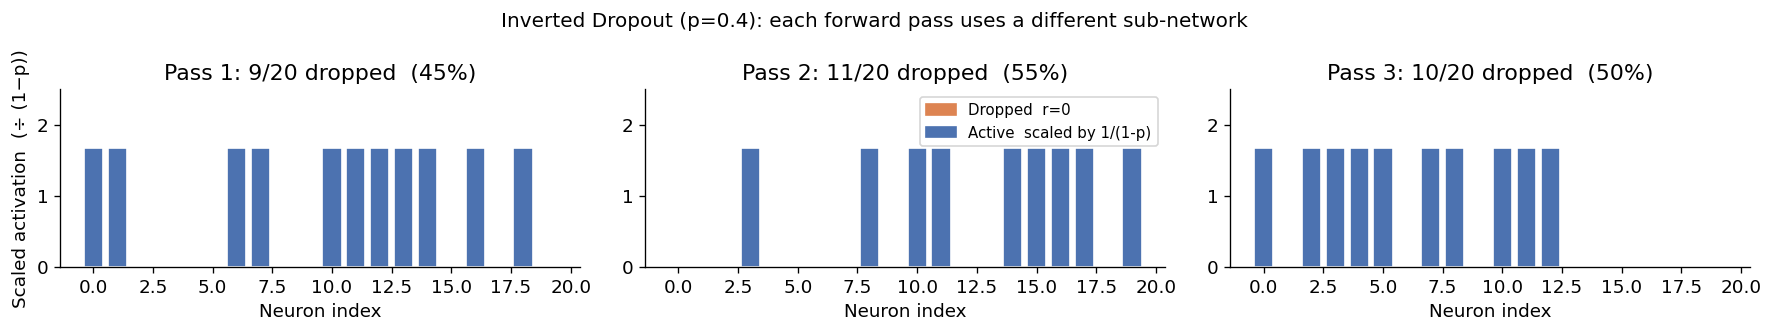

In [37]:
# Visualize inverted dropout masking across three forward passes
torch.manual_seed(7)
drop = nn.Dropout(p=0.4)
x    = torch.ones(1, 20)    # unit activations for clear visualization

fig, axes = plt.subplots(1, 3, figsize=(15, 2.8))
for i, ax in enumerate(axes):
    drop.train()
    out = drop(x.clone()).squeeze(0).numpy()
    colors = ['#DD8452' if v == 0 else '#4C72B0' for v in out]
    ax.bar(range(20), out, color=colors, edgecolor='white')
    n_drop = (out == 0).sum()
    ax.set_title(f'Pass {i+1}: {n_drop}/20 dropped  ({n_drop/20:.0%})')
    ax.set_xlabel('Neuron index'); ax.set_ylim(0, 2.5)
    if i == 0: ax.set_ylabel('Scaled activation  (÷ (1−p))')

dropped = mpatches.Patch(color='#DD8452', label='Dropped  r=0')
active  = mpatches.Patch(color='#4C72B0', label=r'Active  scaled by 1/(1-p)')
axes[1].legend(handles=[dropped, active], loc='upper right', fontsize=9)

plt.suptitle('Inverted Dropout (p=0.4): each forward pass uses a different sub-network',
             fontsize=12)
plt.tight_layout(); plt.show()

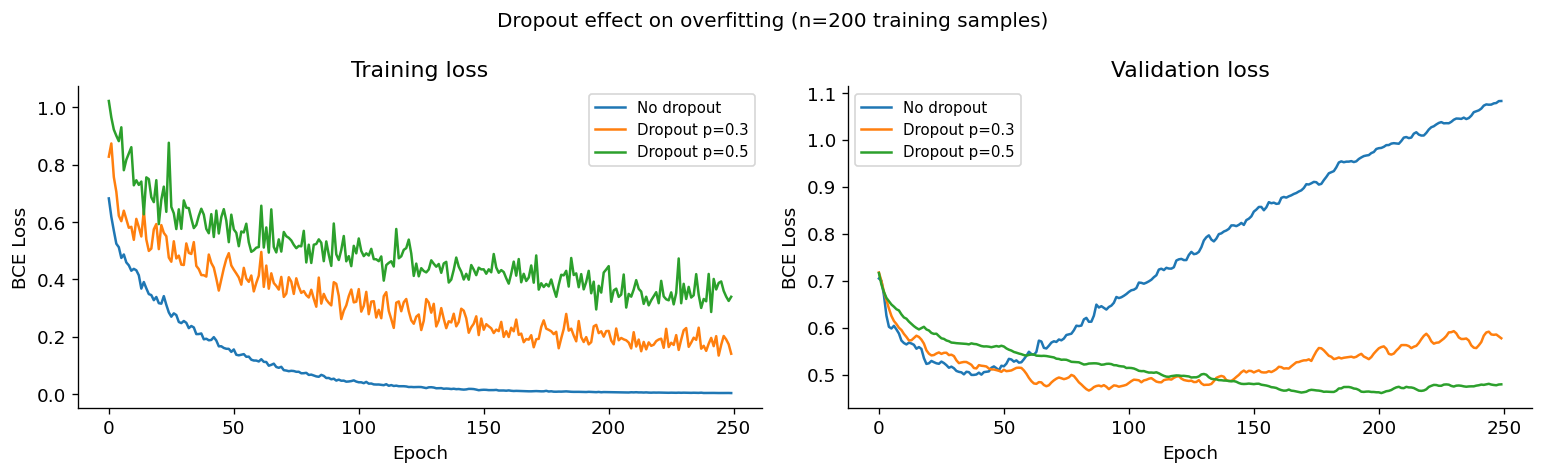

In [38]:
# Dropout effect on train / val loss
configs_do = [
    ('No dropout',       0.0),
    ('Dropout p=0.3',    0.3),
    ('Dropout p=0.5',    0.5),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, p in configs_do:
    torch.manual_seed(42)
    m   = make_mlp(dropout_p=p)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    tr, vl, _ = train_model(m, opt, small_loader, Xval_t, yval_t, n_epochs=250)
    axes[0].plot(tr, label=name); axes[1].plot(vl, label=name)

for ax, t in zip(axes, ['Training loss', 'Validation loss']):
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.set_title(t); ax.legend(fontsize=9)

plt.suptitle('Dropout effect on overfitting (n=200 training samples)', fontsize=12)
plt.tight_layout(); plt.show()

**Зверніть увагу:** training loss при dropout **вища** (мережа вчиться важче), але validation loss **нижча** - це і є сенс регуляризації.

---

## 9. Рання зупинка (Early Stopping) <a id="9"></a>

**Ідея:** зупинити навчання, коли validation loss перестає покращуватись - до того як модель перенавчиться.

### Алгоритм з patience

```
best_val = ∞;  no_improve = 0

for epoch in range(max_epochs):
    train_loss = train_one_epoch()
    val_loss   = evaluate()

    if val_loss < best_val − tol:
        best_val      = val_loss
        best_weights  = copy(model.weights)   # save best checkpoint
        no_improve    = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        model.weights = best_weights          # restore best
        break
```

| Параметр | Роль | Типове значення |
|---|---|---|
| `patience` | кількість "терплячих" епох | 10–30 |
| `tol` | мінімальне значуще покращення | $10^{-4}$ |

> 💡 Early stopping - **безкоштовна форма регуляризації**: зменшує ефективну ємність без зміни архітектури.

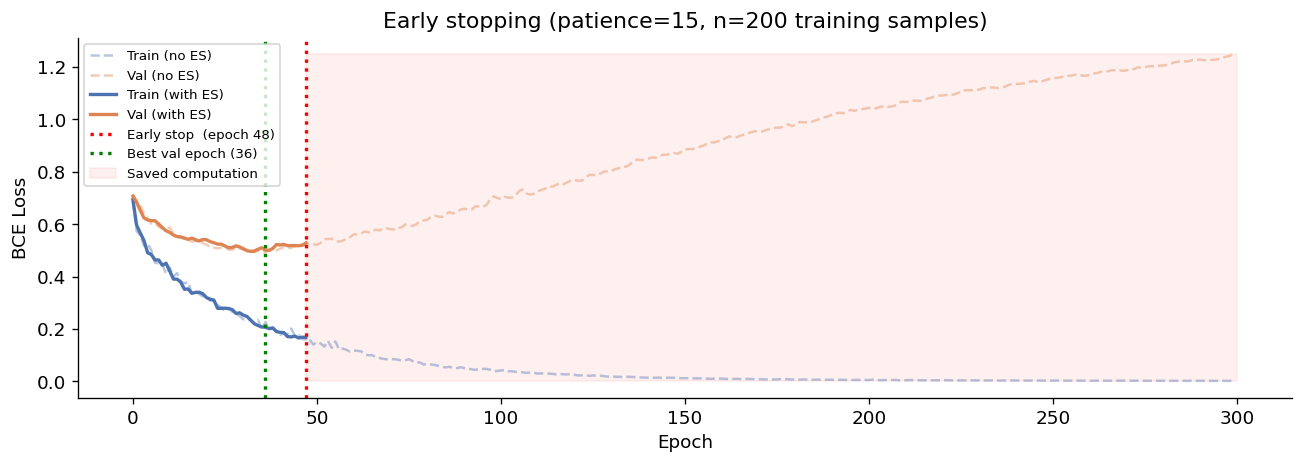

Without ES: 300 epochs  |  With ES: 48 epochs  (252 epochs saved)


In [ ]:
# Visualize the stopping point on train/val curves

# Full run (no early stopping)
torch.manual_seed(42)
m_full = make_mlp()
tr_full, vl_full, _ = train_model(
    m_full, optim.Adam(m_full.parameters(), lr=1e-3),
    small_loader, Xval_t, yval_t, n_epochs=300)

# With early stopping (patience=15)
torch.manual_seed(42)
m_es = make_mlp()
tr_es, vl_es, stop_ep = train_model(
    m_es, optim.Adam(m_es.parameters(), lr=1e-3),
    small_loader, Xval_t, yval_t, n_epochs=300, patience=15)

best_ep = int(np.argmin(vl_full))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tr_full, color=COLORS[0], ls='--', alpha=0.4, label='Train (no ES)')
ax.plot(vl_full, color=COLORS[1], ls='--', alpha=0.4, label='Val (no ES)')
ax.plot(tr_es,   color=COLORS[0], lw=2,              label='Train (with ES)')
ax.plot(vl_es,   color=COLORS[1], lw=2,              label='Val (with ES)')
ax.axvline(stop_ep - 1, color='red',   ls=':', lw=2,
           label=f'Early stop  (epoch {stop_ep})')
ax.axvline(best_ep,     color='green', ls=':', lw=2,
           label=f'Best val epoch ({best_ep})')

ax.fill_betweenx([0, max(vl_full)], stop_ep - 1, len(vl_full),
                  alpha=0.06, color='red', label='Saved computation')

ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Early stopping (patience=15, n=200 training samples)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'Without ES: 300 epochs  |  With ES: {stop_ep} epochs'
      f'  ({300 - stop_ep} epochs saved)')

---

## 10. Ініціалізація ваг <a id="10"></a>

Ініціалізація безпосередньо впливає на **потік градієнтів** на початку навчання.

- **Занадто великі ваги** → насичені активації → зникаючі градієнти
- **Занадто малі ваги** → малі активації → слабкий сигнал навчання
- **Нулі** → симетрія: всі нейрони шару однакові, мережа не вчиться

### Xavier / Glorot (2010)

Підтримує дисперсію активацій однаковою по всіх шарах. Оптимально для `tanh` та `sigmoid`:

$$W \sim \mathcal{U}\!\left(-\sqrt{\frac{6}{n_{in}+n_{out}}},\;\sqrt{\frac{6}{n_{in}+n_{out}}}\right)$$

або нормальний варіант: $W \sim \mathcal{N}\!\left(0,\,\sqrt{\dfrac{2}{n_{in}+n_{out}}}\right)$

### He / Kaiming (2015)

Враховує несиметричність ReLU (≈ половина нейронів нульові). Оптимально для `ReLU`:

$$W \sim \mathcal{N}\!\left(0,\,\sqrt{\frac{2}{n_{in}}}\right)$$

| Активація | Рекомендована ініціалізація |
|---|---|
| `tanh`, `sigmoid` | Xavier |
| `ReLU`, `LeakyReLU` | He (Kaiming) |
| Linear | Xavier або $\mathcal{N}(0, 0.01)$ |

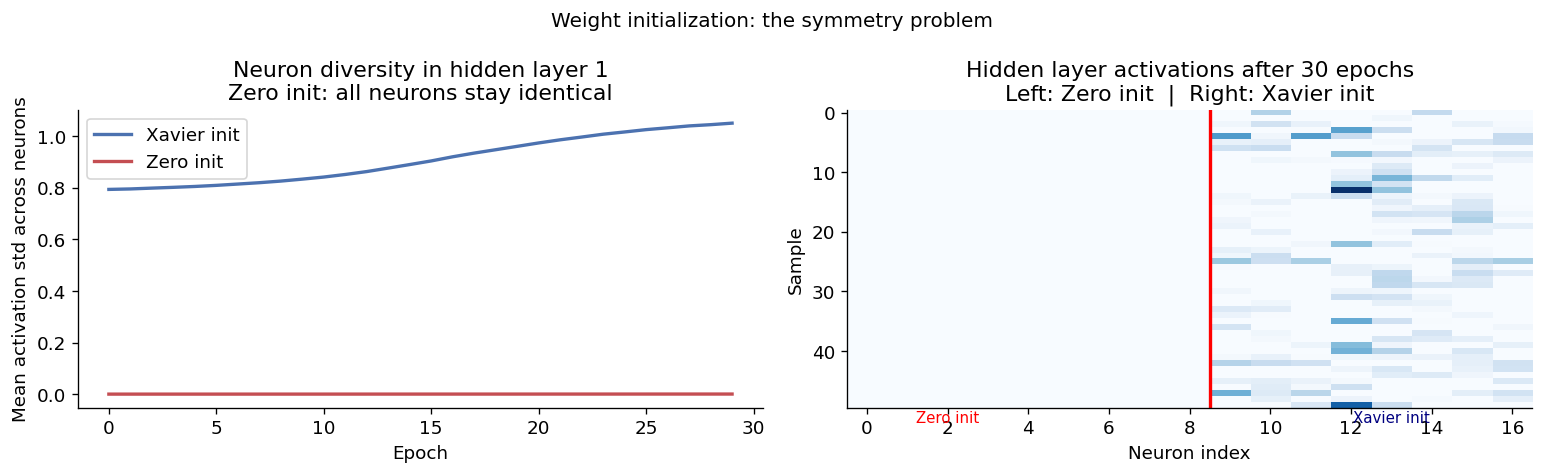

In [47]:
# Weight init: demonstrate the symmetry problem directly.
# All-zero init → all neurons in a layer stay identical forever.
# We show this by tracking how diverse (std) the hidden activations are.

def activation_diversity(init, n_epochs=30):
    """Train a small net; track std of hidden layer activations per epoch."""
    torch.manual_seed(42)
    net = nn.Sequential(
        nn.Linear(20, 8), nn.ReLU(),
        nn.Linear(8,  4), nn.ReLU(),
        nn.Linear(4,  1), nn.Sigmoid()
    ).to(DEVICE)

    if init == 'zeros':
        for layer in net:
            if isinstance(layer, nn.Linear):
                nn.init.zeros_(layer.weight)
    elif init == 'xavier':
        for layer in net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)

    opt  = optim.SGD(net.parameters(), lr=0.05)
    crit = nn.BCELoss()
    diversity = []   # std of first hidden layer activations

    for _ in range(n_epochs):
        net.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            crit(net(xb).squeeze(-1), yb).backward()
            opt.step()

        net.eval()
        with torch.no_grad():
            h1 = net[0](Xtr_t)          # pre-activation of first hidden layer
            h1 = net[1](h1)             # post-ReLU
            diversity.append(h1.std(dim=0).mean().item())  # mean neuron diversity

    return diversity

div_zeros  = activation_diversity('zeros')
div_xavier = activation_diversity('xavier')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: diversity over training
axes[0].plot(div_xavier, color=COLORS[0], lw=2, label='Xavier init')
axes[0].plot(div_zeros,  color=COLORS[3], lw=2, label='Zero init')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Mean activation std across neurons')
axes[0].set_title('Neuron diversity in hidden layer 1\nZero init: all neurons stay identical')
axes[0].legend()

# Right: snapshot of actual neuron activation patterns at epoch 30
net_z = nn.Sequential(nn.Linear(20,8), nn.ReLU(),
                       nn.Linear(8,4),  nn.ReLU(),
                       nn.Linear(4,1),  nn.Sigmoid()).to(DEVICE)
net_x = nn.Sequential(nn.Linear(20,8), nn.ReLU(),
                       nn.Linear(8,4),  nn.ReLU(),
                       nn.Linear(4,1),  nn.Sigmoid()).to(DEVICE)

for net, init_fn in [(net_z, lambda l: nn.init.zeros_(l.weight)),
                     (net_x, lambda l: nn.init.xavier_uniform_(l.weight))]:
    for layer in net:
        if isinstance(layer, nn.Linear):
            init_fn(layer)
    opt = optim.SGD(net.parameters(), lr=0.05)
    crit = nn.BCELoss()
    for _ in range(30):
        for xb, yb in train_loader:
            opt.zero_grad()
            crit(net(xb).squeeze(-1), yb).backward()
            opt.step()

net_z.eval(); net_x.eval()
with torch.no_grad():
    h_z = net_z[1](net_z[0](Xtr_t[:50])).cpu().numpy()  # (50, 8)
    h_x = net_x[1](net_x[0](Xtr_t[:50])).cpu().numpy()

im = axes[1].imshow(np.hstack([h_z, np.zeros((50,1)), h_x]),
                    aspect='auto', cmap='Blues')
axes[1].axvline(8.5, color='red', lw=2)
axes[1].set_title('Hidden layer activations after 30 epochs\n'
                  'Left: Zero init  |  Right: Xavier init')
axes[1].set_xlabel('Neuron index'); axes[1].set_ylabel('Sample')
axes[1].text(2,   52, 'Zero init',   color='red',     fontsize=9, ha='center')
axes[1].text(13,  52, 'Xavier init', color='navy',    fontsize=9, ha='center')

plt.suptitle('Weight initialization: the symmetry problem', fontsize=12)
plt.tight_layout(); plt.show()

**Як читати ці графіки:**

**Ліворуч - різноманітність нейронів з часом.** Вісь Y показує середнє стандартне відхилення активацій між нейронами одного шару: якщо всі 8 нейронів видають однакові значення - std = 0; якщо кожен навчився реагувати на щось своє - std > 0.

- **Zero init:** крива залишається на нулі протягом усього навчання. З нульовими вагами всі нейрони шару отримують однаковий градієнт і оновлюються ідентично - симетрія ніколи не розривається. Мережа фактично працює як мережа з одним нейроном у кожному шарі.
- **Xavier init:** std починається вже близько до 0.8 - різні ваги одразу дають різні активації. З часом std трохи зростає: нейрони **спеціалізуються** в процесі навчання, кожен налаштовується на різні патерни у вхідних даних. Це нормальна і бажана поведінка.

**Праворуч - «відбитки пальців» нейронів після 30 епох.** Кожен рядок - один зразок, кожен стовпець - один нейрон. При Zero init (ліворуч від червоної лінії) всі стовпці однакові - нейрони не розрізняються. При Xavier init - кожен нейрон має власний унікальний патерн активації.


## 11. Batch Normalization: огляд <a id="11"></a>

> 📌 **Цей метод буде детально розглянуто в курсі з глибоких нейронних мереж.** Тут - коротке введення.

**Batch Normalization** (Ioffe & Szegedy, 2015) нормалізує активації кожного шару по міні-батчу:

$$\mu_{\mathcal{B}} = \frac{1}{m}\sum_{i=1}^m z_i \qquad \sigma^2_{\mathcal{B}} = \frac{1}{m}\sum_{i=1}^m(z_i - \mu_{\mathcal{B}})^2$$

$$\hat{z}_i = \frac{z_i - \mu_{\mathcal{B}}}{\sqrt{\sigma^2_{\mathcal{B}} + \varepsilon}} \qquad \text{BN}(z_i) = \gamma\hat{z}_i + \beta$$

де $\gamma$ та $\beta$ - **навчальні параметри** (scale та shift).

### Ефекти
- Стабілізує оптимізацію → можна використовувати більші LR
- Зменшує чутливість до ініціалізації ваг
- Виступає як **неявна регуляризація** (шум від батч-статистики)

### У PyTorch

```python
nn.Sequential(
    nn.Linear(64, 32),
    nn.BatchNorm1d(32),   # after Linear, before activation
    nn.ReLU(),
)
```

| Режим | Поведінка |
|---|---|
| `model.train()` | нормалізація по поточному батчу; оновлення running stats |
| `model.eval()` | нормалізація по running mean/var, накопичених під час тренування |

---

## 12. Порівняльний експеримент <a id="12"></a>

### Мета

Порівняти **6 конфігурацій** по двох осях:
- **Оптимізатор:** SGD+Momentum | Adam | AdamW
- **Регуляризація:** жодної | L2 + Dropout + Early Stopping

| # | Оптимізатор | Регуляризація |
|---|---|---|
| 1 | SGD + Momentum | - |
| 2 | SGD + Momentum | L2 + Dropout(0.3) + ES(patience=20) |
| 3 | Adam | - |
| 4 | Adam | L2 + Dropout(0.3) + ES(patience=20) |
| 5 | AdamW | - |
| 6 | AdamW | L2 + Dropout(0.3) + ES(patience=20) |

Усі конфігурації тренуються на **повному** тренувальному наборі (1200 зразків), He init, lr розумний для кожного оптимізатора.

In [ ]:
# Comparison experiment: optimizer x regularization
N_EP  = 250
PAT   = 20
WD    = 5e-3
DROP  = 0.3

exp_configs = [
    # (display_name,             Opt class,    opt kwargs,                         drop,  early_stop)
    ('SGD+Mom  · no reg',         optim.SGD,    dict(lr=0.05, momentum=0.9),        0.0,   False),
    ('SGD+Mom  · L2+Drop+ES',     optim.SGD,    dict(lr=0.05, momentum=0.9),        DROP,  True),
    ('Adam     · no reg',         optim.Adam,   dict(lr=1e-3),                      0.0,   False),
    ('Adam     · L2+Drop+ES',     optim.Adam,   dict(lr=1e-3, weight_decay=WD),     DROP,  True),
    ('AdamW    · no reg',         optim.AdamW,  dict(lr=1e-3),                      0.0,   False),
    ('AdamW    · L2+Drop+ES',     optim.AdamW,  dict(lr=1e-3, weight_decay=WD),     DROP,  True),
]

exp_results = {}
print(f'{'Config':35s}  epochs  test_acc  gen_gap')
print('-' * 65)
for name, Opt, kw, drop_p, use_es in exp_configs:
    torch.manual_seed(42)
    m   = make_mlp(dropout_p=drop_p, init='he')
    opt = Opt(m.parameters(), **kw)
    tr, vl, ep = train_model(m, opt, train_loader, Xval_t, yval_t,
                              n_epochs=N_EP, patience=PAT if use_es else None)
    acc = accuracy(m, Xte_t, yte_t)
    gap = abs(vl[-1] - tr[-1])
    exp_results[name] = {'train': tr, 'val': vl, 'epochs': ep, 'acc': acc, 'gap': gap}
    print(f'{name:35s}  {ep:5d}  {acc:.4f}    {gap:.4f}')

Config                               epochs  test_acc  gen_gap
-----------------------------------------------------------------
SGD+Mom  · no reg                      250  0.8175    2.9339
SGD+Mom  · L2+Drop+ES                   39  0.8625    0.0457
Adam     · no reg                      250  0.8125    2.1920
Adam     · L2+Drop+ES                   73  0.8625    0.0064
AdamW    · no reg                      250  0.8200    2.1253
AdamW    · L2+Drop+ES                   69  0.8625    0.0027


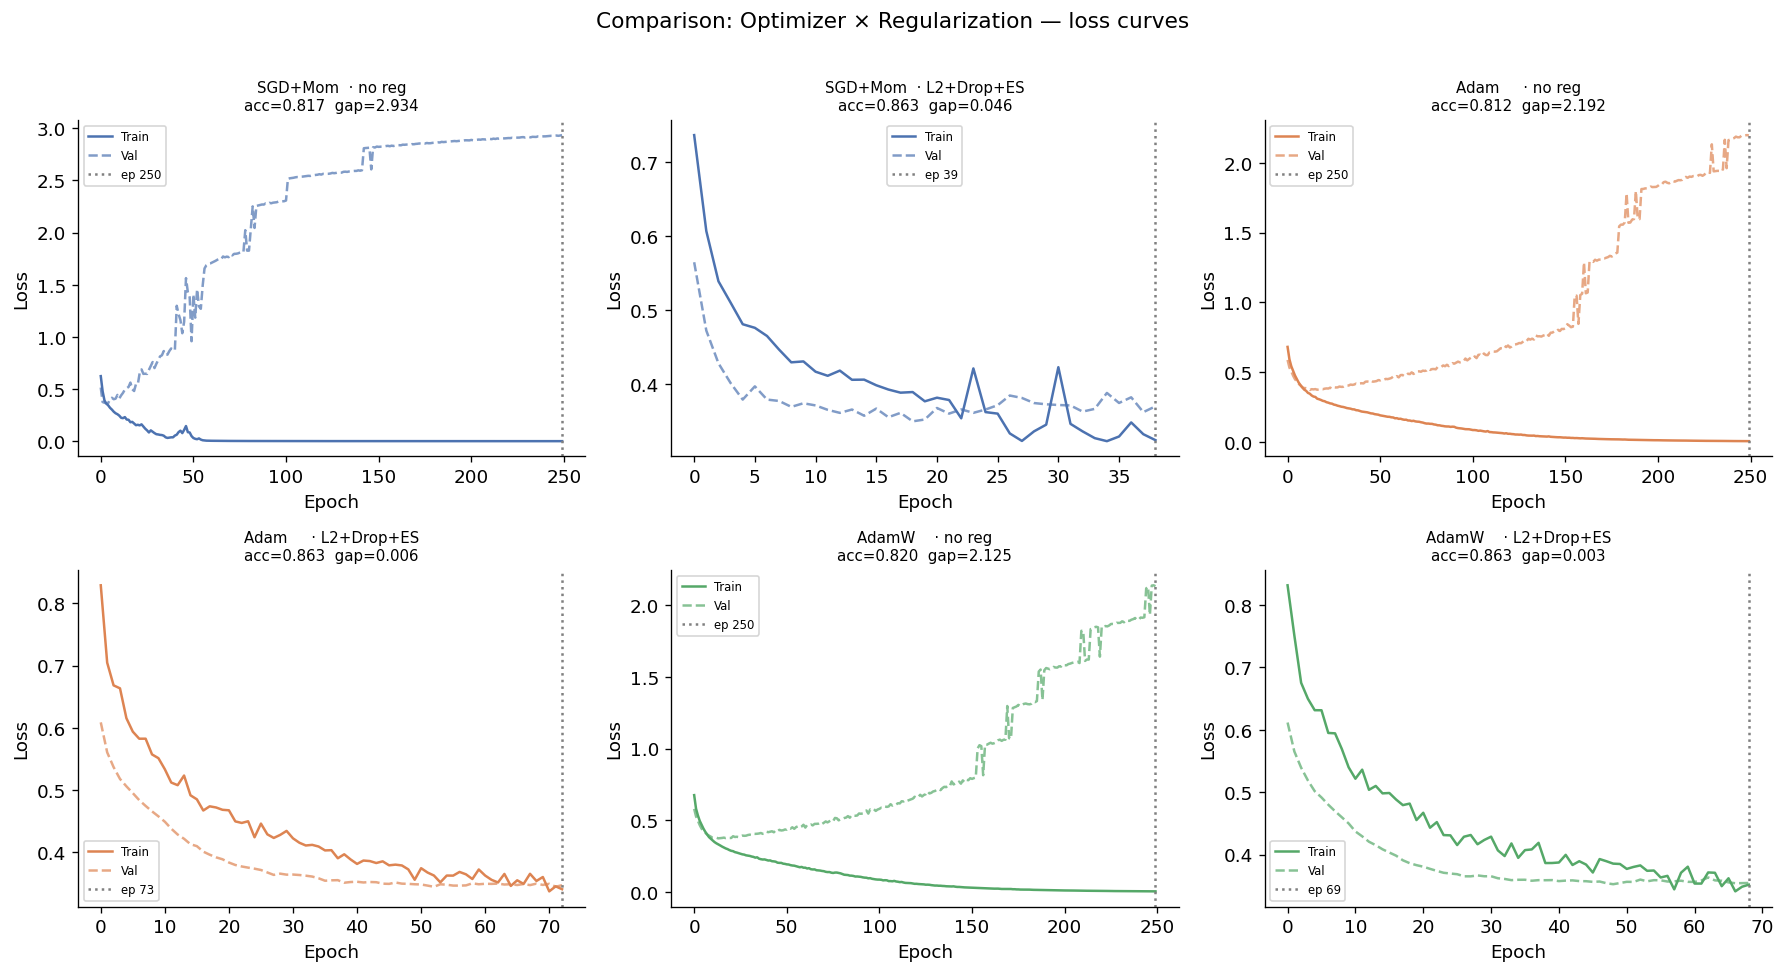

In [ ]:
# Plot loss curves for all 6 configurations (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

opt_colors = {
    'SGD+Mom':  COLORS[0],
    'Adam':     COLORS[1],
    'AdamW':    COLORS[2],
}

for ax, (name, res) in zip(axes.flat, exp_results.items()):
    prefix = name.split()[0]
    c = opt_colors.get(prefix, COLORS[0])
    ax.plot(res['train'], color=c,          lw=1.5, label='Train')
    ax.plot(res['val'],   color=c, ls='--', lw=1.5, alpha=0.7, label='Val')
    ax.axvline(res['epochs'] - 1, color='gray', ls=':', lw=1.5,
               label=f"ep {res['epochs']}")
    ax.set_title(f"{name}\nacc={res['acc']:.3f}  gap={res['gap']:.3f}", fontsize=9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=7)

plt.suptitle('Comparison: Optimizer × Regularization - loss curves', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

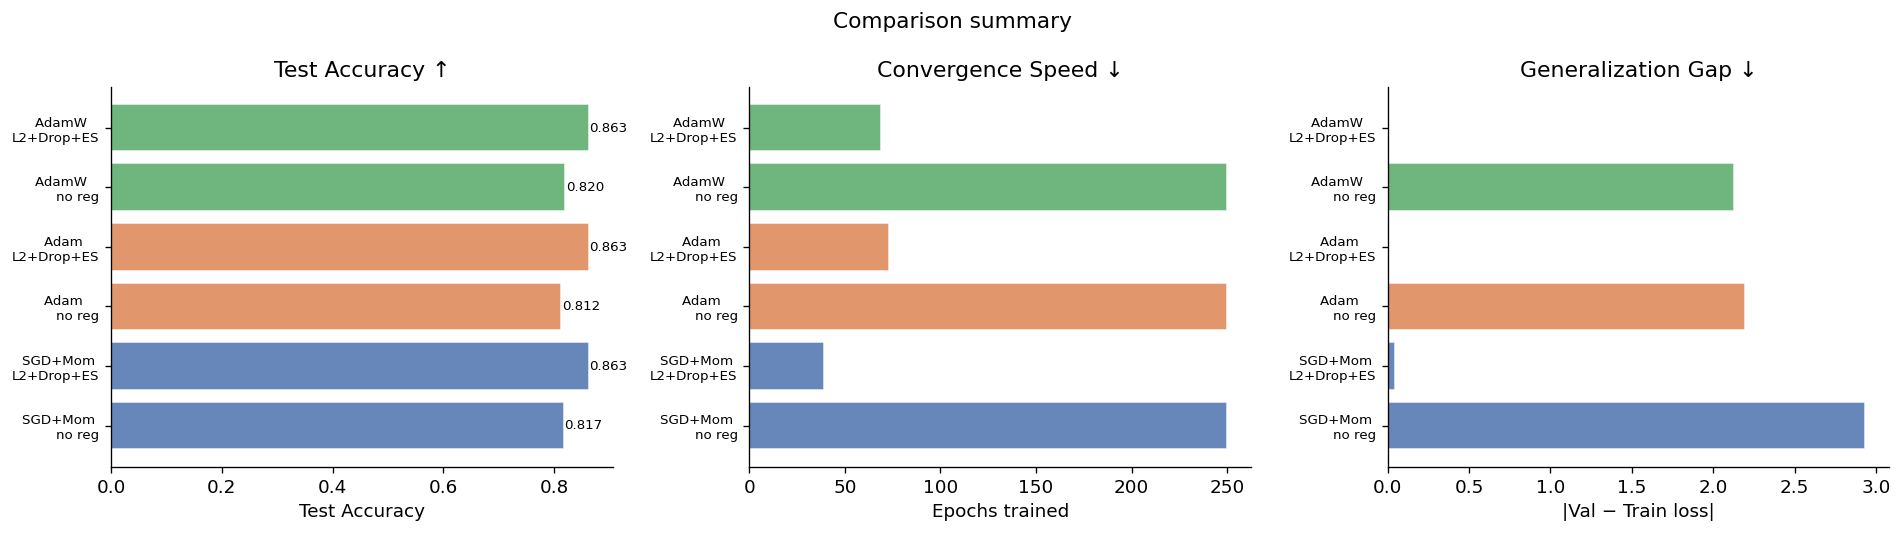

In [ ]:
# Summary bar charts
names_e = list(exp_results.keys())
accs    = [exp_results[n]['acc']    for n in names_e]
eps_r   = [exp_results[n]['epochs'] for n in names_e]
gaps    = [exp_results[n]['gap']    for n in names_e]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.arange(len(names_e))
bar_colors = [COLORS[i // 2] for i in range(len(names_e))]
short = [n.replace(' · ', '\n') for n in names_e]

# Test accuracy
axes[0].barh(x, accs,  color=bar_colors, edgecolor='white', alpha=0.85)
axes[0].set_yticks(x); axes[0].set_yticklabels(short, fontsize=8)
axes[0].set_xlabel('Test Accuracy'); axes[0].set_title('Test Accuracy ↑')
for i, v in enumerate(accs):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# Epochs to converge
axes[1].barh(x, eps_r, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].set_yticks(x); axes[1].set_yticklabels(short, fontsize=8)
axes[1].set_xlabel('Epochs trained'); axes[1].set_title('Convergence Speed ↓')

# Generalization gap
axes[2].barh(x, gaps, color=bar_colors, edgecolor='white', alpha=0.85)
axes[2].set_yticks(x); axes[2].set_yticklabels(short, fontsize=8)
axes[2].set_xlabel('|Val − Train loss|'); axes[2].set_title('Generalization Gap ↓')

plt.suptitle('Comparison summary', fontsize=13)
plt.tight_layout(); plt.show()

---
## 14. Підсумки <a id="summary"></a>

| Метод | Проблема | Ключова формула | PyTorch |
|---|---|---|---|
| **Mini-Batch GD** | Баланс BGD / SGD | $\theta \leftarrow \theta - \frac{\eta}{|B|}\sum_{i\in B}\nabla\mathcal{L}^{(i)}$ | `DataLoader(batch_size=64)` |
| **Momentum** | Ущелини, повільна збіжність | $v_t = \beta v_{t-1} + \nabla\mathcal{L}$ | `SGD(momentum=0.9)` |
| **Nesterov** | Те ж, але точніший | Градієнт у "майбутній" позиції | `SGD(nesterov=True)` |
| **RMSProp** | Адаптивний LR | $s_t = \rho s_{t-1}+(1-\rho)g^2$ | `optim.RMSprop` |
| **Adam** | Momentum + адаптивний LR | $m_t, v_t$ + bias correction | `optim.Adam(lr=1e-3)` |
| **AdamW** | Правильний weight decay | Decoupled $\lambda\theta$ | `optim.AdamW(wd=1e-2)` |
| **LR Scheduling** | Фіксований LR неоптимальний | CosineAnnealing, Plateau... | `lr_scheduler.*` |
| **Grad Clipping** | Вибухаючі градієнти | $g \leftarrow cg/\|g\|_2$ | `clip_grad_norm_` |
| **L2 / Weight Decay** | Великі ваги → overfit | $\mathcal{L}+\frac{\lambda}{2}\|\theta\|^2$ | `weight_decay` в оптимізаторі |
| **Dropout** | Co-adaptation нейронів | $\tilde{a}=ra/(1-p)$ | `nn.Dropout(p=0.3)` |
| **Early Stopping** | Перенавчання | Зупинка при зростанні val loss | Явний цикл + patience |
| **He / Xavier Init** | Зникаючі/вибухаючі градієнти | $W\sim\mathcal{N}(0,\sqrt{2/n_{in}})$ | `nn.init.kaiming_*` |
| **Batch Norm** | Covariate shift | $\hat{z}=(z-\mu)/\sigma$, потім $\gamma\hat{z}+\beta$ | `nn.BatchNorm1d` |

### Практичні рекомендації

> 🏆 **Рекомендований стартовий набір:**  
> `AdamW` + `He init` + `Dropout(0.3)` + `weight_decay=1e-2` + `CosineAnnealingLR` + `EarlyStopping(patience=20)`